# Natural Disaster Impact Modelling Code

## Section 1: Set-Up and Data Loading

In [1]:
# =============================================================================
# IMPORTS & CONFIGURATION
# STA6704 | Natural Disaster Severity Classification
# =============================================================================

import warnings
warnings.filterwarnings("ignore")

# ── Core ──────────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import time
import scipy.sparse as sp

# ── Visualization ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns

# ── Scikit-learn: Preprocessing ───────────────────────────────────────────────
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (StandardScaler, OneHotEncoder,
                                   LabelEncoder, label_binarize)
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# ── Scikit-learn: Model Selection ─────────────────────────────────────────────
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     StratifiedShuffleSplit, cross_val_score)

# ── Scikit-learn: Feature Selection ───────────────────────────────────────────
from sklearn.feature_selection import VarianceThreshold

# ── Scikit-learn: Linear Models ───────────────────────────────────────────────
from sklearn.linear_model import (LogisticRegression, LogisticRegressionCV,
                                  RidgeClassifier, LassoCV, ElasticNetCV)

# ── Scikit-learn: Ensemble Models ─────────────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier

# ── Scikit-learn: SVM ─────────────────────────────────────────────────────────
from sklearn.svm import SVC, LinearSVC
from sklearn.calibration import CalibratedClassifierCV

# ── Scikit-learn: Neural Network ──────────────────────────────────────────────
from sklearn.neural_network import MLPClassifier

# ── Scikit-learn: Metrics ─────────────────────────────────────────────────────
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    f1_score, accuracy_score, balanced_accuracy_score,
    precision_score, recall_score,
    cohen_kappa_score, matthews_corrcoef, log_loss,
    roc_auc_score, roc_curve, auc,
    precision_recall_curve, average_precision_score
)

# ── Scikit-learn: Utilities ───────────────────────────────────────────────────
from sklearn.utils.class_weight import compute_sample_weight, compute_class_weight

# ── Imbalanced-learn ──────────────────────────────────────────────────────────
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# ── Statsmodels ───────────────────────────────────────────────────────────────
import statsmodels.api as sm

# ── XGBoost ───────────────────────────────────────────────────────────────────
import xgboost as xgb

# ── PyTorch (Neural Network GPU section) ──────────────────────────────────────
try:
    import torch
    import torch.nn as nn
    import torch.optim as optim
    TORCH_AVAILABLE = True
    print(f"PyTorch available — device: {'cuda' if torch.cuda.is_available() else 'cpu'}")
except ImportError:
    TORCH_AVAILABLE = False
    print("PyTorch not installed — GPU MLP section will be skipped.")

# ── Joblib ────────────────────────────────────────────────────────────────────
import joblib

# =============================================================================
# PROJECT-WIDE CONSTANTS
# =============================================================================

RANDOM_STATE = 6704
CLASS_ORDER  = ["None", "Low", "Medium", "High", "Catastrophic"]

print(f"\nAll imports loaded successfully.")
print(f"Random state : {RANDOM_STATE}")
print(f"Class order  : {CLASS_ORDER}")

# =============================================================================
# DATA LOADING
# =============================================================================

# ── OPTION A: Load from Google Drive (Colab) ──────────────────────────────────
# import gdown, re
# FOLDER_URL = "https://drive.google.com/drive/folders/1zmEEdvAyvqZAQsVsMvyKRmk2c-A2lGOj?usp=drive_link"
# match = re.search(r'/folders/([^/?]+)', FOLDER_URL)
# folder_id = match.group(1) if match else FOLDER_URL
# gdown.download_folder(id=folder_id, quiet=False, use_cookies=False)
# df = pd.read_csv("Raw Files/disaster_merged.csv")

# ── OPTION B: Load locally ────────────────────────────────────────────────────
df = pd.read_csv(r"G:\My Drive\DMM2 Project\Raw Files\disaster_merged.csv")

print(f"Loaded: {df.shape[0]:,} rows, {df.shape[1]} columns")
print(f"Columns: {df.columns.tolist()}")

PyTorch available — device: cpu

All imports loaded successfully.
Random state : 6704
Class order  : ['None', 'Low', 'Medium', 'High', 'Catastrophic']
Loaded: 3,777,888 rows, 30 columns
Columns: ['EVENT_ID', 'STATE', 'STATE_ABBREV', 'YEAR', 'MONTH', 'BEGIN_DATE', 'EVENT_TYPE', 'CZ_NAME', 'CZ_TYPE', 'DEATHS_DIRECT', 'DEATHS_INDIRECT', 'INJURIES_DIRECT', 'INJURIES_INDIRECT', 'DAMAGE_PROPERTY_USD', 'DAMAGE_CROPS_USD', 'MAGNITUDE', 'MAGNITUDE_TYPE', 'BEGIN_LAT', 'BEGIN_LON', 'SOURCE', 'FATALITY_COUNT', 'FATALITY_AGE_AVG', 'FEMA_INCIDENT_TYPE', 'response_days', 'ihProgramDeclared', 'iaProgramDeclared', 'paProgramDeclared', 'DATA_SOURCE', 'COUNTRY', 'DAMAGE_TOTAL_USD']


## Section 2: Data Cleaning & Preprocessing

In [2]:
# =============================================================================
# SECTION 1: Load Data
# =============================================================================

# ── COLAB: Download from shared Google Drive folder ───────────────────────────
# import gdown, re
# FOLDER_URL = "https://drive.google.com/drive/folders/1zmEEdvAyvqZAQsVsMvyKRmk2c-A2lGOj?usp=drive_link"
# match = re.search(r'/folders/([^/?]+)', FOLDER_URL)
# folder_id = match.group(1) if match else FOLDER_URL
# gdown.download_folder(id=folder_id, quiet=False, use_cookies=False)
# df = pd.read_csv("Raw Files/disaster_merged.csv")

# ── LOCAL: Load directly from disk ────────────────────────────────────────────
df = pd.read_csv(r"G:\My Drive\DMM2 Project\Raw Files\disaster_merged.csv")
print(f"Loaded: {df.shape[0]:,} rows, {df.shape[1]} columns")

# =============================================================================
# SECTION 2: Initial Review
# =============================================================================

# Quick missingness overview on raw data
col_info = pd.DataFrame({
    "dtype"      : df.dtypes,
    "pct_missing": (df.isnull().mean() * 100).round(1),
    "n_unique"   : df.nunique()
})
print(f"\nTotal columns: {len(df.columns)}\n")
print(col_info.to_string())

# Confirm FEMA join is causing duplicates (diagnostic — can skip on re-runs)
sample = df[df["EVENT_ID"] == 5165377]
print(sample[["EVENT_ID", "FEMA_INCIDENT_TYPE", "response_days"]].drop_duplicates())

# =============================================================================
# SECTION 3: Exact Deduplication
# =============================================================================

cleaned_df = df.drop_duplicates()
print(f"After exact dedup: {len(cleaned_df):,} rows (was {len(df):,})")

# Confirm multi-row events still remain (from FEMA join)
remaining_per_event = cleaned_df.groupby("EVENT_ID").size()
print(f"Events with >1 remaining row: {(remaining_per_event > 1).sum():,} out of {len(remaining_per_event):,}")

# =============================================================================
# SECTION 4: Fatality Column Handling
# =============================================================================

# FATALITY_COUNT is null when no death occurred — confirmed negligible mismatch
# (191 events with DEATHS_DIRECT > 0 but no fatality record, all <= 10 deaths)
# Drop sparse fatality columns; use DEATHS_DIRECT/DEATHS_INDIRECT as authoritative

cleaned_df["DEATHS_TOTAL"] = cleaned_df["DEATHS_DIRECT"] + cleaned_df["DEATHS_INDIRECT"]
cleaned_df = cleaned_df.drop(columns=["FATALITY_COUNT", "FATALITY_AGE_AVG"])

print(f"After fatality column removal: {len(cleaned_df):,} rows, {len(cleaned_df.columns)} columns")

# =============================================================================
# SECTION 5: FEMA Type Validation and Aggregation
# =============================================================================

# Map NOAA EVENT_TYPE to valid FEMA incidentType categories
# Mismatched FEMA rows (e.g. Thunderstorm Wind matched to "Fire") are nulled out
EVENT_TO_FEMA_TYPE = {
    "Hurricane (Typhoon)":      ["Hurricane", "Typhoon", "Tropical Storm"],
    "Tropical Storm":           ["Hurricane", "Typhoon", "Tropical Storm"],
    "Tropical Depression":      ["Hurricane", "Typhoon", "Tropical Storm"],
    "Storm Surge/Tide":         ["Hurricane", "Typhoon", "Tropical Storm", "Flood"],
    "Flood":                    ["Flood"],
    "Flash Flood":              ["Flood"],
    "Coastal Flood":            ["Flood"],
    "Lakeshore Flood":          ["Flood"],
    "Tornado":                  ["Tornado", "Severe Storm(s)"],
    "Funnel Cloud":             ["Tornado", "Severe Storm(s)"],
    "Thunderstorm Wind":        ["Severe Storm(s)"],
    "High Wind":                ["Severe Storm(s)"],
    "Strong Wind":              ["Severe Storm(s)"],
    "Hail":                     ["Severe Storm(s)"],
    "Lightning":                ["Severe Storm(s)"],
    "Wildfire":                 ["Fire"],
    "Drought":                  ["Fire"],
    "Blizzard":                 ["Snow", "Severe Ice Storm"],
    "Winter Storm":             ["Snow", "Severe Ice Storm"],
    "Winter Weather":           ["Snow", "Severe Ice Storm"],
    "Ice Storm":                ["Severe Ice Storm"],
    "Heavy Snow":               ["Snow"],
    "Lake-Effect Snow":         ["Snow"],
    "Cold/Wind Chill":          ["Snow", "Severe Ice Storm"],
    "Extreme Cold/Wind Chill":  ["Snow", "Severe Ice Storm"],
    "Frost/Freeze":             ["Snow"],
    "Debris Flow":              ["Mud/Landslide"],
    "Landslide":                ["Mud/Landslide"],
    "Avalanche":                ["Mud/Landslide", "Snow"],
    "Tsunami":                  ["Tsunami"],
    "Volcanic Ash":             ["Volcano"],
    "Astronomical Low Tide":    [],
    "Dense Fog":                [],
    "Dense Smoke":              ["Fire"],
    "Dust Devil":               [],
    "Dust Storm":               [],
    "Excessive Heat":           [],
    "Heat":                     [],
    "Heavy Rain":               ["Flood"],
    "High Surf":                ["Hurricane", "Typhoon", "Tropical Storm"],
    "Rip Current":              [],
    "Seiche":                   [],
    "Sleet":                    ["Snow", "Severe Ice Storm"],
    "Waterspout":               [],
}

fema_cols = ["FEMA_INCIDENT_TYPE", "response_days",
             "ihProgramDeclared", "iaProgramDeclared", "paProgramDeclared"]

cleaned_df["VALID_FEMA_TYPES"] = cleaned_df["EVENT_TYPE"].map(EVENT_TO_FEMA_TYPE)

def is_valid_match(row):
    valid_types = row["VALID_FEMA_TYPES"]
    return pd.notna(row["FEMA_INCIDENT_TYPE"]) and row["FEMA_INCIDENT_TYPE"] in valid_types

mask_valid = cleaned_df.apply(is_valid_match, axis=1)

print(f"Rows with a FEMA match      : {cleaned_df['FEMA_INCIDENT_TYPE'].notna().sum():,}")
print(f"Rows with a VALID FEMA match: {mask_valid.sum():,}")
print(f"Rows being nulled out       : {(cleaned_df['FEMA_INCIDENT_TYPE'].notna() & ~mask_valid).sum():,}")

cleaned_df.loc[~mask_valid, fema_cols] = pd.NA
cleaned_df = cleaned_df.drop(columns=["VALID_FEMA_TYPES"])

# Aggregate FEMA columns to one row per EVENT_ID
cleaned_df["HAS_VALID_FEMA_MATCH"] = cleaned_df["FEMA_INCIDENT_TYPE"].notna()

noaa_cols = [c for c in cleaned_df.columns if c not in fema_cols]
events_unique = cleaned_df[noaa_cols].drop_duplicates(subset="EVENT_ID")

fema_agg = (
    cleaned_df.groupby("EVENT_ID")
    .agg(
        FEMA_MATCH_COUNT  = ("FEMA_INCIDENT_TYPE", "count"),
        AVG_RESPONSE_DAYS = ("response_days", "mean"),
        MIN_RESPONSE_DAYS = ("response_days", "min"),
        MAX_RESPONSE_DAYS = ("response_days", "max"),
        ANY_IH_DECLARED   = ("ihProgramDeclared", "max"),
        ANY_IA_DECLARED   = ("iaProgramDeclared", "max"),
        ANY_PA_DECLARED   = ("paProgramDeclared", "max"),
    )
    .reset_index()
)

clean_fema = events_unique.merge(fema_agg, on="EVENT_ID", how="left")

dupes_remaining = clean_fema["EVENT_ID"].duplicated().sum()
assert dupes_remaining == 0, f"Still have {dupes_remaining} duplicate EVENT_IDs"
print(f"clean_fema shape: {clean_fema.shape} — one row per EVENT_ID confirmed")

# =============================================================================
# SECTION 6: Drop FEMA Columns Entirely
# NOTE: After validation, only 7% of events had a valid FEMA match,
# concentrated in Drought/Flood/Wildfire. FEMA dropped to avoid noise.
# =============================================================================

fema_related_cols = [
    "FEMA_INCIDENT_TYPE", "response_days",
    "ihProgramDeclared", "iaProgramDeclared", "paProgramDeclared",
    "FEMA_MATCH_COUNT", "AVG_RESPONSE_DAYS", "MIN_RESPONSE_DAYS",
    "MAX_RESPONSE_DAYS", "ANY_IH_DECLARED", "ANY_IA_DECLARED",
    "ANY_PA_DECLARED", "HAS_VALID_FEMA_MATCH"
]

cols_to_drop = [c for c in fema_related_cols if c in clean_fema.columns]
final_df = clean_fema.drop(columns=cols_to_drop)
print(f"After FEMA removal: {final_df.shape[0]:,} rows, {final_df.columns.tolist().__len__()} columns")

# =============================================================================
# SECTION 7: Damage Column Fixes
# =============================================================================

# NaN in damage = genuinely unknown (not zero)
# NOAA records explicit $0 separately (727K+ rows) — NaN preserved intentionally
final_df["DAMAGE_PROPERTY_REPORTED"] = final_df["DAMAGE_PROPERTY_USD"].notna()
final_df["DAMAGE_CROPS_REPORTED"]    = final_df["DAMAGE_CROPS_USD"].notna()

# Combine damage: NaN only when BOTH source columns are missing
def combine_damage(row):
    prop = row["DAMAGE_PROPERTY_USD"]
    crop = row["DAMAGE_CROPS_USD"]
    if pd.isna(prop) and pd.isna(crop):
        return pd.NA
    if pd.isna(prop):
        return crop
    if pd.isna(crop):
        return prop
    return prop + crop

final_df["DAMAGE_TOTAL_USD"]          = final_df.apply(combine_damage, axis=1)
final_df["DAMAGE_TOTAL_USD"]          = pd.to_numeric(final_df["DAMAGE_TOTAL_USD"], errors="coerce")
final_df["DAMAGE_TOTAL_USD_REPORTED"] = final_df["DAMAGE_TOTAL_USD"].notna()

print(f"DAMAGE_TOTAL_USD missing: {(final_df['DAMAGE_TOTAL_USD'].isnull().mean() * 100).round(1)}%")

# =============================================================================
# SECTION 8: Drop Latitude/Longitude
# =============================================================================

# 41% missing, concentrated in forecast-zone records (99% missing for CZ_TYPE Z)
# STATE and CZ_NAME retained for geographic granularity
final_df = final_df.drop(columns=["BEGIN_LAT", "BEGIN_LON"])
print(f"Columns after lat/lon drop: {len(final_df.columns)}")

# =============================================================================
# SECTION 9: Magnitude Applicability Flag
# =============================================================================

# MAGNITUDE only meaningful for 4 event types: Hail, Thunderstorm Wind,
# High Wind, Strong Wind. Missingness is structural, not a data gap.
final_df["MAGNITUDE_APPLICABLE"] = final_df["MAGNITUDE"].notna()
print(f"MAGNITUDE_APPLICABLE:\n{final_df['MAGNITUDE_APPLICABLE'].value_counts()}")

# =============================================================================
# SECTION 10: Fix STATE_ABBREV — Marine/Offshore Zones
# =============================================================================

# 0.3% of records list water body names (Gulf of Mexico, Great Lakes, etc.)
# rather than a US state. Labeled explicitly as MARINE.
missing_state_rows = final_df[final_df["STATE_ABBREV"].isnull()]
print(f"Rows with missing STATE_ABBREV: {len(missing_state_rows):,}")
print(missing_state_rows["STATE"].value_counts())

final_df.loc[final_df["STATE_ABBREV"].isnull(), "STATE_ABBREV"] = "MARINE"
print(f"Remaining null STATE_ABBREV: {final_df['STATE_ABBREV'].isnull().sum()}")

# =============================================================================
# SECTION 11: Target Variable Construction — SEVERITY_CLASS
# =============================================================================

# Severity scored on 3 dimensions (deaths, injuries, damage), each capped 0-3
# to prevent damage dollars from dominating. Thresholds based on empirical
# percentile distributions within the training data.

def death_score(d):
    if d == 0:    return 0
    elif d <= 2:  return 1
    elif d <= 13: return 2
    else:         return 3

def injury_score(i):
    if i == 0:    return 0
    elif i <= 3:  return 1
    elif i <= 18: return 2
    else:         return 3

def damage_score(d):
    if pd.isna(d) or d == 0:   return 0
    elif d <= 30_000:           return 1
    elif d <= 600_000:          return 2
    else:                       return 3

def severity_class(score):
    if score == 0:   return "None"
    elif score <= 2: return "Low"
    elif score <= 5: return "Medium"
    elif score <= 7: return "High"
    else:            return "Catastrophic"

total_injuries = final_df["INJURIES_DIRECT"] + final_df["INJURIES_INDIRECT"]

final_df["DEATH_SCORE"]       = final_df["DEATHS_TOTAL"].apply(death_score)
final_df["INJURY_SCORE"]      = total_injuries.apply(injury_score)
final_df["DAMAGE_SCORE"]      = final_df["DAMAGE_TOTAL_USD"].apply(damage_score)
final_df["SEVERITY_COMPOSITE"] = (
    final_df["DEATH_SCORE"] + final_df["INJURY_SCORE"] + final_df["DAMAGE_SCORE"]
)
final_df["SEVERITY_CLASS"]    = final_df["SEVERITY_COMPOSITE"].apply(severity_class)

print(final_df["SEVERITY_CLASS"].value_counts())
print(f"\n% in each class:")
print((final_df["SEVERITY_CLASS"].value_counts(normalize=True) * 100).round(2))

# =============================================================================
# SECTION 12: Final Dataset Summary
# =============================================================================

final_col_info = pd.DataFrame({
    "dtype"      : final_df.dtypes,
    "pct_missing": (final_df.isnull().mean() * 100).round(1),
    "n_unique"   : final_df.nunique()
})
print(f"\nFINAL DATASET SHAPE: {final_df.shape[0]:,} rows, {final_df.shape[1]} columns")
print(final_col_info.to_string())

# =============================================================================
# SECTION 13: Stratified Train/Val/Test Split (70/15/15)
# =============================================================================

from sklearn.model_selection import train_test_split

X = final_df.drop(columns=["SEVERITY_CLASS", "SEVERITY_COMPOSITE",
                            "DEATH_SCORE", "INJURY_SCORE", "DAMAGE_SCORE"])
y = final_df["SEVERITY_CLASS"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=6704
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=6704
)

print(f"Train: {len(X_train):,} rows ({len(X_train)/len(final_df)*100:.1f}%)")
print(f"Val  : {len(X_val):,} rows ({len(X_val)/len(final_df)*100:.1f}%)")
print(f"Test : {len(X_test):,} rows ({len(X_test)/len(final_df)*100:.1f}%)")

print("\nRaw counts per class:")
print(pd.DataFrame({
    "train": y_train.value_counts(),
    "val"  : y_val.value_counts(),
    "test" : y_test.value_counts()
}))

Loaded: 3,777,888 rows, 30 columns

Total columns: 30

                       dtype  pct_missing  n_unique
EVENT_ID               int64          0.0   1546474
STATE                 object          0.0        68
STATE_ABBREV          object          0.1        55
YEAR                   int64          0.0        26
MONTH                  int64          0.0        12
BEGIN_DATE            object          0.0      9486
EVENT_TYPE            object          0.0        43
CZ_NAME               object          0.0      5066
CZ_TYPE               object          0.0         3
DEATHS_DIRECT          int64          0.0        48
DEATHS_INDIRECT        int64          0.0        22
INJURIES_DIRECT        int64          0.0       135
INJURIES_INDIRECT      int64          0.0        66
DAMAGE_PROPERTY_USD  float64         27.5      2172
DAMAGE_CROPS_USD     float64         31.8      1121
MAGNITUDE            float64         51.8       440
MAGNITUDE_TYPE        object         71.1         6
BEGIN_LAT

## Section 3: EDA

Shape: (1546474, 31)

Column types:
int64      12
object     11
float64     4
bool        4
Name: count, dtype: int64

Descriptive statistics (numeric):
           EVENT_ID          YEAR         MONTH  DEATHS_DIRECT  \
count  1.546474e+06  1.546474e+06  1.546474e+06   1.546474e+06   
mean   1.721442e+06  2.013076e+03  6.002087e+00   1.059313e-02   
std    2.000871e+06  7.452088e+00  3.062937e+00   6.136114e-01   
min    3.000000e+00  2.000000e+03  1.000000e+00   0.000000e+00   
25%    4.176582e+05  2.007000e+03  4.000000e+00   0.000000e+00   
50%    8.395575e+05  2.013000e+03  6.000000e+00   0.000000e+00   
75%    1.267182e+06  2.020000e+03  8.000000e+00   0.000000e+00   
max    5.535308e+06  2.025000e+03  1.200000e+01   6.380000e+02   

       DEATHS_INDIRECT  INJURIES_DIRECT  INJURIES_INDIRECT  \
count     1.546474e+06     1.546474e+06       1.546474e+06   
mean      2.885273e-03     4.139158e-02       1.011721e-02   
std       1.058625e-01     2.274093e+00       2.049327e+00   
min 

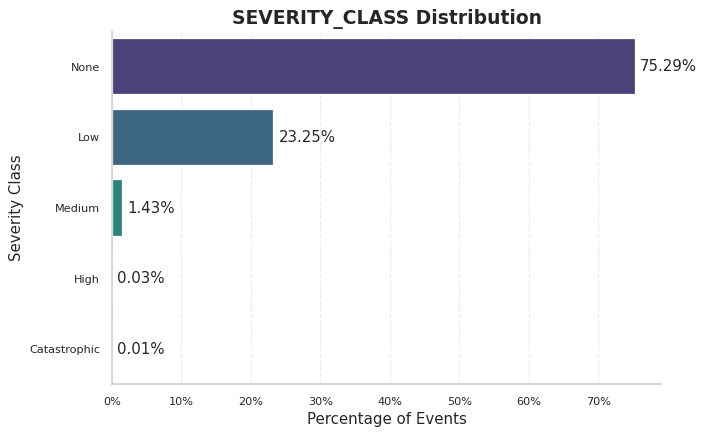

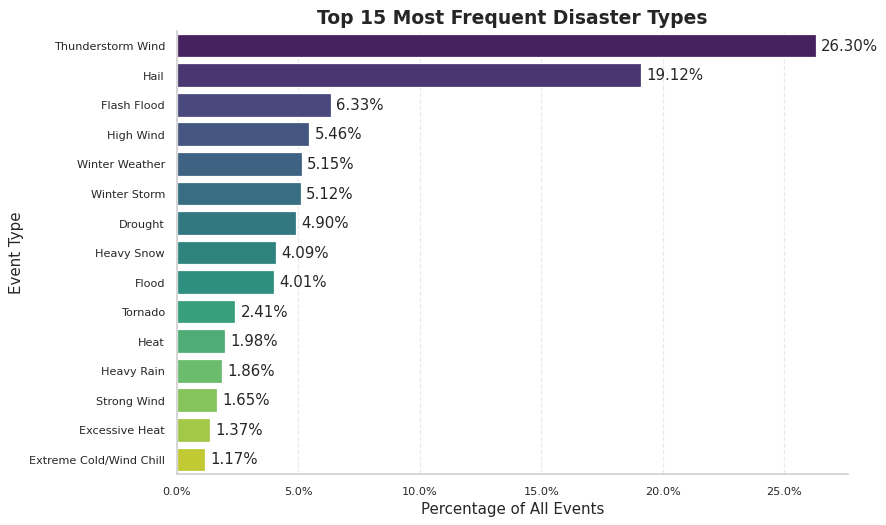

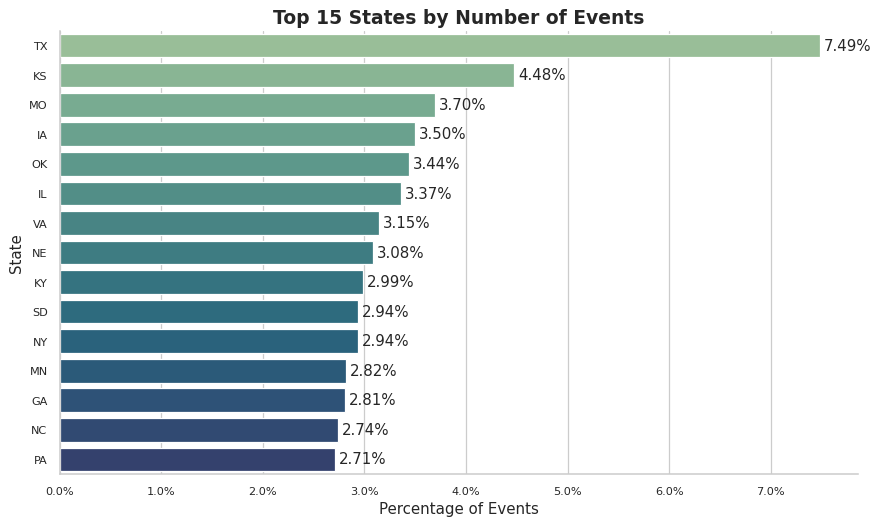

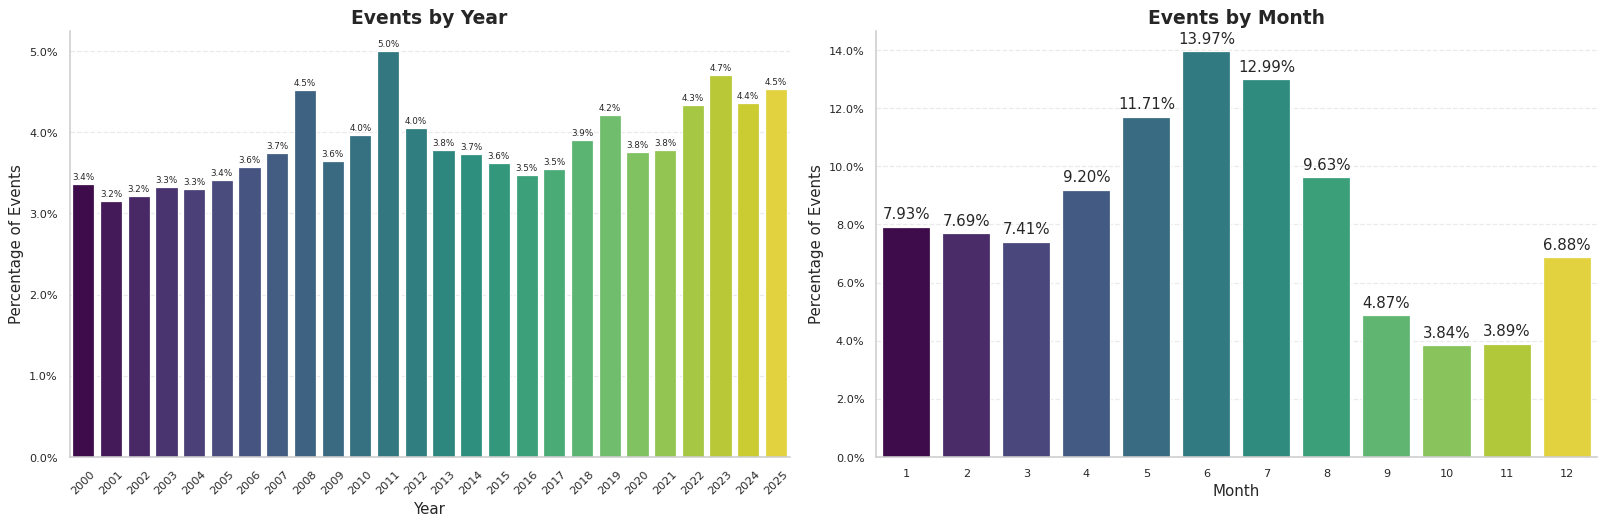

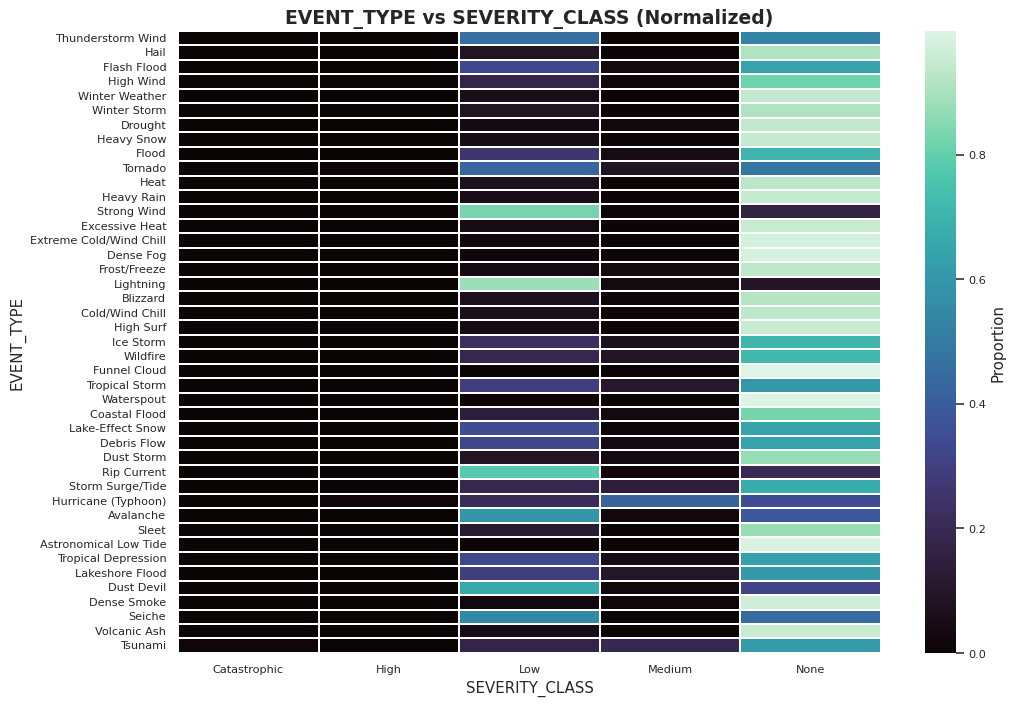

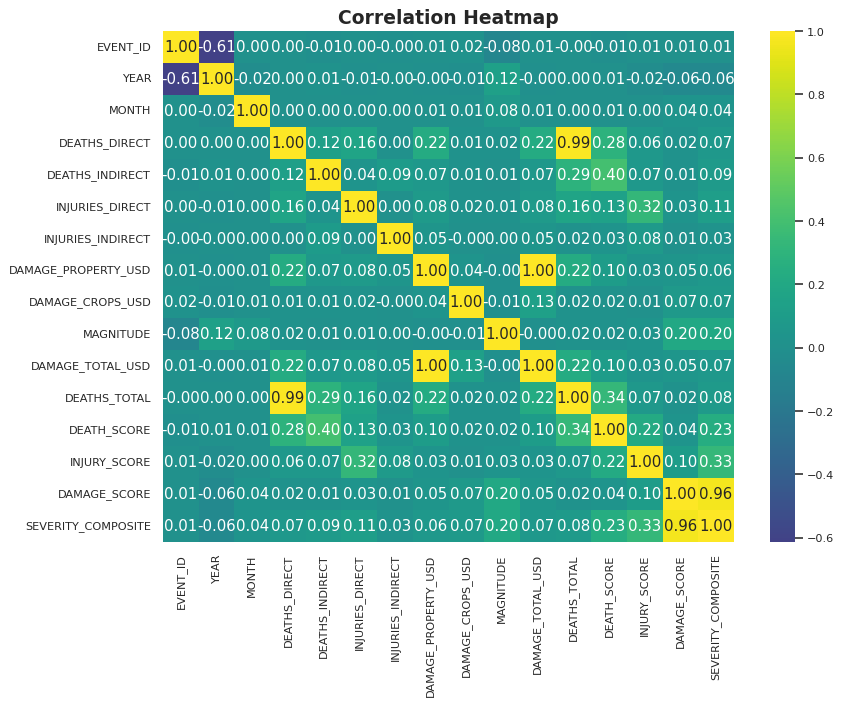

In [3]:
# ── VISUALIZATION SETTINGS ───────────────────────────────────────────────────
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi"        : 90,
    "axes.titlesize"    : 12,
    "axes.titleweight"  : "bold",
    "axes.labelsize"    : 12,
    "xtick.labelsize"   : 9,
    "ytick.labelsize"   : 9,
    "legend.fontsize"   : 12,
    "font.family"       : "DejaVu Sans"
})

# =============================================================================
# SECTION 1: Dataset Overview
# =============================================================================

print(f"Shape: {final_df.shape}")
print(f"\nColumn types:")
print(final_df.dtypes.value_counts())
print(f"\nDescriptive statistics (numeric):")
print(final_df.describe())

# =============================================================================
# SECTION 2: Missing Values
# =============================================================================

missing = pd.DataFrame({
    "Missing": final_df.isnull().sum(),
    "Percent": round(final_df.isnull().mean() * 100, 2)
})
missing = missing[missing["Missing"] > 0].sort_values("Percent", ascending=False)
print("\nMissing values summary:")
print(missing.to_string())

# Duplicate check (should be 0 after preprocessing)
print(f"\nDuplicate rows remaining: {final_df.duplicated().sum()}")

# =============================================================================
# SECTION 3: Target Variable Distribution
# =============================================================================

dist     = final_df["SEVERITY_CLASS"].value_counts()
dist_pct = dist / len(final_df) * 100

plt.figure(figsize=(8, 5))
ax = sns.barplot(x=dist_pct.values, y=dist_pct.index,
                 hue=dist_pct.index, palette="viridis", legend=False)
plt.title("SEVERITY_CLASS Distribution", fontsize=15, weight="bold")
plt.xlabel("Percentage of Events")
plt.ylabel("Severity Class")
ax.xaxis.set_major_formatter(mticker.PercentFormatter())
plt.grid(axis="x", linestyle="--", alpha=0.4)
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%", padding=4)
sns.despine()
plt.tight_layout()
plt.show()

# =============================================================================
# SECTION 4: Event Type Distribution (Top 15)
# =============================================================================

top_n         = 15
event_counts  = final_df["EVENT_TYPE"].value_counts().head(top_n)
event_percent = event_counts / len(final_df) * 100

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=event_percent.values, y=event_percent.index,
                 hue=event_percent.index, palette="viridis", legend=False)
plt.title(f"Top {top_n} Most Frequent Disaster Types", fontsize=15, weight="bold")
plt.xlabel("Percentage of All Events")
plt.ylabel("Event Type")
ax.xaxis.set_major_formatter(mticker.PercentFormatter())
plt.grid(axis="x", linestyle="--", alpha=0.4)
for container in ax.containers:
    ax.bar_label(container,
                 labels=[f"{v:.2f}%" for v in container.datavalues],
                 padding=4)
sns.despine()
plt.tight_layout()
plt.show()

# =============================================================================
# SECTION 5: State Distribution (Top 15)
# =============================================================================

state_counts  = final_df["STATE_ABBREV"].value_counts().head(top_n)
state_percent = state_counts / len(final_df) * 100

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=state_percent.values, y=state_percent.index,
                 hue=state_percent.index, palette="crest", legend=False)
plt.title(f"Top {top_n} States by Number of Events", fontsize=15, weight="bold")
plt.xlabel("Percentage of Events")
plt.ylabel("State")
ax.xaxis.set_major_formatter(mticker.PercentFormatter())
for container in ax.containers:
    ax.bar_label(container,
                 labels=[f"{v:.2f}%" for v in container.datavalues],
                 padding=3)
sns.despine()
plt.tight_layout()
plt.show()

# =============================================================================
# SECTION 6: Temporal Distributions (Year and Month)
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# By Year
dist_year     = final_df["YEAR"].value_counts().sort_index()
dist_year_pct = dist_year / len(final_df) * 100

sns.barplot(x=dist_year.index, y=dist_year_pct.values,
            hue=dist_year.index, palette="viridis",
            legend=False, ax=axes[0])
axes[0].set_title("Events by Year", fontsize=15, weight="bold")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Percentage of Events")
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter())
axes[0].grid(axis="y", linestyle="--", alpha=0.4)
axes[0].tick_params(axis="x", rotation=45)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%.1f%%", padding=2, fontsize=7)

# By Month
dist_month     = final_df["MONTH"].value_counts().sort_index()
dist_month_pct = dist_month / len(final_df) * 100

sns.barplot(x=dist_month.index, y=dist_month_pct.values,
            hue=dist_month.index, palette="viridis",
            legend=False, ax=axes[1])
axes[1].set_title("Events by Month", fontsize=15, weight="bold")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Percentage of Events")
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter())
axes[1].grid(axis="y", linestyle="--", alpha=0.4)
for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%.2f%%", padding=4)

sns.despine()
plt.tight_layout()
plt.show()

# =============================================================================
# SECTION 7: Event Type vs. Severity Class Heatmap
# =============================================================================

ct     = pd.crosstab(final_df["EVENT_TYPE"], final_df["SEVERITY_CLASS"])
ct_pct = ct.div(ct.sum(axis=1), axis=0)
ct_pct = ct_pct.loc[ct.sum(axis=1).sort_values(ascending=False).index]

plt.figure(figsize=(12, 8))
sns.heatmap(ct_pct, cmap="mako", annot=False,
            linewidths=0.3, linecolor="white",
            cbar_kws={"label": "Proportion"})
plt.title("EVENT_TYPE vs SEVERITY_CLASS (Normalized)", fontsize=15, weight="bold")
plt.xlabel("SEVERITY_CLASS")
plt.ylabel("EVENT_TYPE")
plt.tight_layout()
plt.show()

# =============================================================================
# SECTION 8: Correlation Heatmap
# =============================================================================

num_df = final_df.select_dtypes(include=np.number)
corr   = num_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap="viridis", annot=True, fmt=".2f", center=0)
plt.title("Correlation Heatmap", fontsize=15, weight="bold")
plt.tight_layout()
plt.show()

## Section 4: Feature Selection

Encoded feature count: 121

Low-variance features to drop: 50
['STATE_ABBREV_AS', 'STATE_ABBREV_AZ', 'STATE_ABBREV_CT', 'STATE_ABBREV_DC', 'STATE_ABBREV_DE', 'STATE_ABBREV_GU', 'STATE_ABBREV_HI', 'STATE_ABBREV_ID', 'STATE_ABBREV_MA', 'STATE_ABBREV_MARINE', 'STATE_ABBREV_ME', 'STATE_ABBREV_NH', 'STATE_ABBREV_NV', 'STATE_ABBREV_OR', 'STATE_ABBREV_PR', 'STATE_ABBREV_RI', 'STATE_ABBREV_UT', 'STATE_ABBREV_VI', 'STATE_ABBREV_VT', 'STATE_ABBREV_WA', 'EVENT_TYPE_Avalanche', 'EVENT_TYPE_Blizzard', 'EVENT_TYPE_Coastal Flood', 'EVENT_TYPE_Cold/Wind Chill', 'EVENT_TYPE_Debris Flow', 'EVENT_TYPE_Dense Smoke', 'EVENT_TYPE_Dust Devil', 'EVENT_TYPE_Dust Storm', 'EVENT_TYPE_Frost/Freeze', 'EVENT_TYPE_Funnel Cloud', 'EVENT_TYPE_High Surf', 'EVENT_TYPE_Hurricane (Typhoon)', 'EVENT_TYPE_Ice Storm', 'EVENT_TYPE_Lake-Effect Snow', 'EVENT_TYPE_Lakeshore Flood', 'EVENT_TYPE_Lightning', 'EVENT_TYPE_Rip Current', 'EVENT_TYPE_Seiche', 'EVENT_TYPE_Sleet', 'EVENT_TYPE_Storm Surge/Tide', 'EVENT_TYPE_Tropical Depres

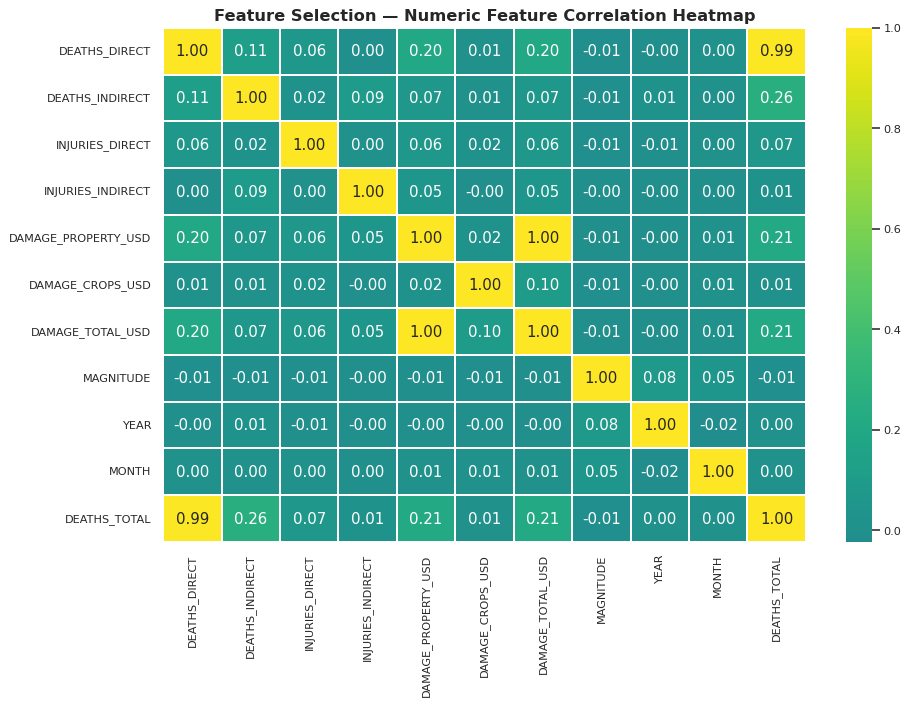

Stepwise selected features: 99

Optimal alpha (Lasso): 0.008444
Features retained    : 58
Features zeroed out  : 63

Optimal alpha (ElasticNet): 0.016888
Optimal l1_ratio          : 0.5000
Features retained         : 58

=== Full Feature Comparison Table ===
                                    Stepwise  Lasso_Coef  Lasso_Selected  ENet_Coef  ENet_Selected  Consensus_Count
DAMAGE_TOTAL_USD_REPORTED                  1    0.283658               1   0.254970              1                3
MAGNITUDE_TYPE_EG                          1    0.119877               1   0.116121              1                3
EVENT_TYPE_Tornado                         1    0.099397               1   0.097085              1                3
EVENT_TYPE_Lightning                       1    0.074407               1   0.073081              1                3
EVENT_TYPE_Flash Flood                     1    0.057817               1   0.054160              1                3
YEAR                                       1 

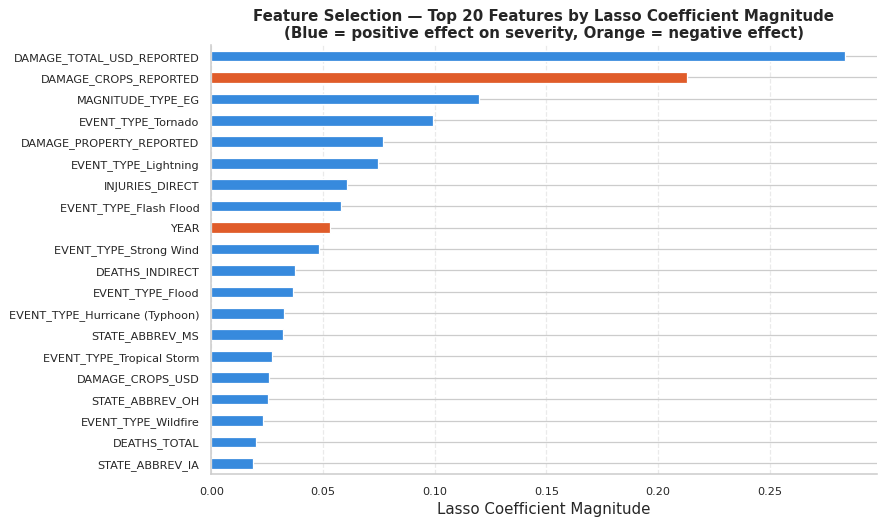

Final feature count after leakage removal: 51

Final confirmed features:
['MAGNITUDE_TYPE_EG', 'EVENT_TYPE_Tornado', 'EVENT_TYPE_Lightning', 'EVENT_TYPE_Flash Flood', 'YEAR', 'EVENT_TYPE_Strong Wind', 'EVENT_TYPE_Flood', 'EVENT_TYPE_Hurricane (Typhoon)', 'STATE_ABBREV_MS', 'EVENT_TYPE_Tropical Storm', 'STATE_ABBREV_OH', 'EVENT_TYPE_Wildfire', 'STATE_ABBREV_IA', 'EVENT_TYPE_Rip Current', 'STATE_ABBREV_VT', 'MAGNITUDE', 'STATE_ABBREV_NY', 'EVENT_TYPE_Ice Storm', 'STATE_ABBREV_MT', 'CZ_TYPE_Z', 'STATE_ABBREV_IL', 'STATE_ABBREV_MO', 'STATE_ABBREV_SD', 'EVENT_TYPE_Winter Weather', 'STATE_ABBREV_HI', 'STATE_ABBREV_CO', 'STATE_ABBREV_WY', 'STATE_ABBREV_WV', 'EVENT_TYPE_Storm Surge/Tide', 'EVENT_TYPE_Heavy Snow', 'STATE_ABBREV_TN', 'STATE_ABBREV_KS', 'EVENT_TYPE_Avalanche', 'EVENT_TYPE_Heavy Rain', 'EVENT_TYPE_Funnel Cloud', 'STATE_ABBREV_MA', 'STATE_ABBREV_MN', 'STATE_ABBREV_NJ', 'EVENT_TYPE_Debris Flow', 'EVENT_TYPE_Hail', 'STATE_ABBREV_WA', 'STATE_ABBREV_GA', 'EVENT_TYPE_Excessive Heat', 'E

In [4]:
# =============================================================================
# SECTION 1: Encoding
# =============================================================================

drop_cols_enc = ["DATA_SOURCE", "COUNTRY", "STATE", "BEGIN_DATE", "CZ_NAME", "SOURCE"]

X_train_rf = X_train.drop(columns=drop_cols_enc)
X_val_rf   = X_val.drop(columns=drop_cols_enc)
X_test_rf  = X_test.drop(columns=drop_cols_enc)

for df_ in [X_train_rf, X_val_rf, X_test_rf]:
    df_["MAGNITUDE_TYPE"] = df_["MAGNITUDE_TYPE"].fillna("Not Applicable")

categorical_cols = ["STATE_ABBREV", "EVENT_TYPE", "CZ_TYPE", "MAGNITUDE_TYPE"]

X_train_enc = pd.get_dummies(X_train_rf, columns=categorical_cols, drop_first=True)
X_val_enc   = pd.get_dummies(X_val_rf,   columns=categorical_cols, drop_first=True)
X_test_enc  = pd.get_dummies(X_test_rf,  columns=categorical_cols, drop_first=True)

X_val_enc  = X_val_enc.reindex(columns=X_train_enc.columns, fill_value=0)
X_test_enc = X_test_enc.reindex(columns=X_train_enc.columns, fill_value=0)

X_train_enc = X_train_enc.fillna(0)
X_val_enc   = X_val_enc.fillna(0)
X_test_enc  = X_test_enc.fillna(0)

print(f"Encoded feature count: {X_train_enc.shape[1]}")

# =============================================================================
# SECTION 2: Filter Method — Variance + Correlation
# =============================================================================

selector = VarianceThreshold(threshold=0.01)
selector.fit(X_train_enc)
low_variance_cols = X_train_enc.columns[~selector.get_support()]
print(f"\nLow-variance features to drop: {len(low_variance_cols)}")
print(low_variance_cols.tolist())

numeric_cols_fs = ["DEATHS_DIRECT", "DEATHS_INDIRECT", "INJURIES_DIRECT",
                   "INJURIES_INDIRECT", "DAMAGE_PROPERTY_USD", "DAMAGE_CROPS_USD",
                   "DAMAGE_TOTAL_USD", "MAGNITUDE", "YEAR", "MONTH", "DEATHS_TOTAL"]
numeric_cols_fs = [c for c in numeric_cols_fs if c in X_train_enc.columns]

corr_matrix = X_train_enc[numeric_cols_fs].corr()
print("\nCorrelation matrix (numeric features):")
print(corr_matrix.round(2))

# ── Correlation Heatmap ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="viridis",
            center=0, linewidths=0.3, linecolor="white", ax=ax)
ax.set_title("Feature Selection — Numeric Feature Correlation Heatmap",
             fontsize=13, weight="bold")
plt.tight_layout()
plt.show()

# =============================================================================
# SECTION 3: Wrapper Method — Bidirectional Stepwise Selection
# NOTE: Pre-loaded from a prior run (~198 minutes on full training set).
# To re-run: uncomment the stepwise_selection call below.
# =============================================================================

def stepwise_selection(X, y, initial_features=[],
                       threshold_in=0.01, threshold_out=0.05,
                       verbose=True):
    """
    Bidirectional stepwise selection based on p-values.
    At each step: add the most significant feature below threshold_in,
    then remove the least significant feature above threshold_out.
    """
    included = list(initial_features)
    X = sm.add_constant(X)

    while True:
        changed  = False
        excluded = list(set(X.columns) - set(included) - {"const"})

        if excluded:
            new_pvalues = pd.Series(index=excluded, dtype=float)
            for new_col in excluded:
                try:
                    model = sm.OLS(y, X[["const"] + included + [new_col]]).fit()
                    new_pvalues[new_col] = model.pvalues[new_col]
                except Exception as e:
                    print(f"Error adding {new_col}: {e}")
                    new_pvalues[new_col] = 1.0
            valid_pvalues = new_pvalues[new_pvalues < 1.0]
            if not valid_pvalues.empty and valid_pvalues.min() < threshold_in:
                best_feature = valid_pvalues.idxmin()
                included.append(best_feature)
                changed = True
                if verbose:
                    print(f"Add  {best_feature:30} p={valid_pvalues.min():.6f}")

        if included:
            try:
                model    = sm.OLS(y, X[["const"] + included]).fit()
                pvalues  = model.pvalues.drop("const", errors="ignore").dropna()
                if not pvalues.empty and pvalues.max() > threshold_out:
                    worst_feature = pvalues.idxmax()
                    included.remove(worst_feature)
                    changed = True
                    if verbose:
                        print(f"Drop {worst_feature:30} p={pvalues.max():.6f}")
            except Exception as e:
                print(f"Error in backward step: {e}")

        if not changed:
            break

    return included

for col in X_train_enc.select_dtypes(include="bool").columns:
    X_train_enc[col] = X_train_enc[col].astype(int)
for col in X_train_enc.select_dtypes(include="object").columns:
    X_train_enc[col] = pd.to_numeric(X_train_enc[col], errors="coerce")
X_train_enc = X_train_enc.fillna(0)

y_train_numeric = final_df.loc[X_train.index, "SEVERITY_COMPOSITE"]

# ── PRE-LOADED RESULT (99 features, ~198 minutes to run) ──────────────────────
# To re-run: uncomment below
# start = time.time()
# selected_features_stepwise = stepwise_selection(X_train_enc, y_train_numeric, verbose=True)
# print(f"\nTime elapsed: {(time.time()-start)/60:.1f} minutes")

selected_features_stepwise = [
    'EVENT_TYPE_Flood', 'DAMAGE_TOTAL_USD_REPORTED', 'EVENT_TYPE_Heavy Rain',
    'STATE_ABBREV_MN', 'EVENT_TYPE_Tropical Storm', 'EVENT_TYPE_Dense Fog',
    'STATE_ABBREV_WY', 'EVENT_TYPE_Extreme Cold/Wind Chill', 'STATE_ABBREV_VT',
    'EVENT_TYPE_Heat', 'EVENT_TYPE_Lightning', 'EVENT_TYPE_Strong Wind',
    'EVENT_TYPE_Winter Storm', 'EVENT_TYPE_Winter Weather',
    'EVENT_TYPE_Thunderstorm Wind', 'EVENT_TYPE_High Surf', 'STATE_ABBREV_MT',
    'EVENT_TYPE_Tornado', 'EVENT_TYPE_Ice Storm', 'STATE_ABBREV_IA', 'CZ_TYPE_Z',
    'EVENT_TYPE_Flash Flood', 'STATE_ABBREV_SD', 'STATE_ABBREV_IL',
    'STATE_ABBREV_CO', 'STATE_ABBREV_MS', 'STATE_ABBREV_GA', 'YEAR',
    'STATE_ABBREV_OH', 'MAGNITUDE_TYPE_MG', 'EVENT_TYPE_Heavy Snow',
    'EVENT_TYPE_High Wind', 'MAGNITUDE_TYPE_MS', 'EVENT_TYPE_Rip Current',
    'STATE_ABBREV_NY', 'EVENT_TYPE_Wildfire', 'STATE_ABBREV_MO',
    'MAGNITUDE_TYPE_EG', 'EVENT_TYPE_Hurricane (Typhoon)', 'STATE_ABBREV_WV',
    'STATE_ABBREV_TN', 'STATE_ABBREV_VA', 'STATE_ABBREV_HI', 'STATE_ABBREV_NJ',
    'EVENT_TYPE_Storm Surge/Tide', 'EVENT_TYPE_Avalanche', 'EVENT_TYPE_Debris Flow',
    'EVENT_TYPE_Funnel Cloud', 'STATE_ABBREV_MA', 'EVENT_TYPE_Excessive Heat',
    'STATE_ABBREV_WA', 'EVENT_TYPE_Waterspout', 'STATE_ABBREV_AZ',
    'STATE_ABBREV_PA', 'MAGNITUDE_TYPE_Not Applicable', 'MAGNITUDE',
    'STATE_ABBREV_KS', 'EVENT_TYPE_Dust Devil', 'EVENT_TYPE_Coastal Flood',
    'STATE_ABBREV_OR', 'EVENT_TYPE_Lake-Effect Snow', 'STATE_ABBREV_MD',
    'STATE_ABBREV_AS', 'EVENT_TYPE_Tropical Depression',
    'EVENT_TYPE_Lakeshore Flood', 'STATE_ABBREV_UT', 'STATE_ABBREV_GU',
    'STATE_ABBREV_NH', 'STATE_ABBREV_NE', 'EVENT_TYPE_Frost/Freeze',
    'EVENT_TYPE_Cold/Wind Chill', 'STATE_ABBREV_LA', 'STATE_ABBREV_CT',
    'STATE_ABBREV_MI', 'STATE_ABBREV_WI', 'STATE_ABBREV_DE', 'MAGNITUDE_TYPE_M',
    'EVENT_TYPE_Tsunami', 'CZ_TYPE_M', 'STATE_ABBREV_FL', 'STATE_ABBREV_PR',
    'STATE_ABBREV_RI', 'MAGNITUDE_TYPE_ES', 'STATE_ABBREV_IN', 'STATE_ABBREV_TX',
    'STATE_ABBREV_NV', 'STATE_ABBREV_SC', 'EVENT_TYPE_Dust Storm',
    'STATE_ABBREV_DC', 'STATE_ABBREV_AR', 'MONTH', 'EVENT_TYPE_Seiche',
    'STATE_ABBREV_NC', 'STATE_ABBREV_VI', 'EVENT_TYPE_Dense Smoke',
    'EVENT_TYPE_Hail', 'MAGNITUDE_APPLICABLE', 'STATE_ABBREV_MARINE',
    'STATE_ABBREV_ND'
]

print(f"Stepwise selected features: {len(selected_features_stepwise)}")

# =============================================================================
# SECTION 4: Embedded Methods — Lasso and ElasticNet
# =============================================================================

scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_enc)
X_val_scaled   = scaler.transform(X_val_enc)
X_test_scaled  = scaler.transform(X_test_enc)

# Lasso
lasso = LassoCV(cv=5, random_state=6704, max_iter=10000, n_jobs=-1)
lasso.fit(X_train_scaled, y_train_numeric)

lasso_coefs = pd.Series(lasso.coef_, index=X_train_enc.columns)
print(f"\nOptimal alpha (Lasso): {lasso.alpha_:.6f}")
print(f"Features retained    : {(lasso_coefs != 0).sum()}")
print(f"Features zeroed out  : {(lasso_coefs == 0).sum()}")

# ElasticNet
enet = ElasticNetCV(cv=5, random_state=6704, max_iter=10000, n_jobs=-1)
enet.fit(X_train_scaled, y_train_numeric)

enet_coefs = pd.Series(enet.coef_, index=X_train_enc.columns)
print(f"\nOptimal alpha (ElasticNet): {enet.alpha_:.6f}")
print(f"Optimal l1_ratio          : {enet.l1_ratio_:.4f}")
print(f"Features retained         : {(enet_coefs != 0).sum()}")

# =============================================================================
# SECTION 5: Consensus Comparison Table
# =============================================================================

comparison = pd.DataFrame(index=X_train_enc.columns.tolist())

comparison["Stepwise"]        = comparison.index.isin(selected_features_stepwise).astype(int)
comparison["Lasso_Coef"]      = lasso_coefs
comparison["Lasso_Selected"]  = (lasso_coefs != 0).astype(int)
comparison["ENet_Coef"]       = enet_coefs
comparison["ENet_Selected"]   = (enet_coefs != 0).astype(int)
comparison["Consensus_Count"] = (
    comparison["Stepwise"] +
    comparison["Lasso_Selected"] +
    comparison["ENet_Selected"]
)

comparison = comparison.sort_values(
    ["Consensus_Count", "Lasso_Coef"],
    ascending=[False, False],
    key=lambda x: x.abs() if x.name == "Lasso_Coef" else x
)

print("\n=== Full Feature Comparison Table ===")
print(comparison.to_string())

all_three = comparison[comparison["Consensus_Count"] == 3]
print("\n=== Features selected by ALL 3 methods ===")
print(all_three[["Stepwise", "Lasso_Coef", "ENet_Coef"]].to_string())

print(f"\nTotal selected by all 3  : {len(all_three)}")
print(f"Total selected by 2 of 3 : {(comparison['Consensus_Count'] == 2).sum()}")
print(f"Total selected by 1 of 3 : {(comparison['Consensus_Count'] == 1).sum()}")
print(f"Total selected by none   : {(comparison['Consensus_Count'] == 0).sum()}")

final_features = comparison[comparison["Consensus_Count"] >= 2].index.tolist()
print(f"\nFinal confirmed feature set (>=2 of 3 methods): {len(final_features)} features")

# ── Lasso Coefficient Bar Chart — Top 20 ─────────────────────────────────────
top_lasso = (
    comparison[comparison["Lasso_Selected"] == 1]["Lasso_Coef"]
    .abs()
    .sort_values(ascending=False)
    .head(20)
)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#E05C2A" if comparison.loc[f, "Lasso_Coef"] < 0 else "#378ADD"
          for f in top_lasso.index]
top_lasso.iloc[::-1].plot(kind="barh", ax=ax, color=colors[::-1], edgecolor="white")
ax.set_xlabel("Lasso Coefficient Magnitude")
ax.set_title("Feature Selection — Top 20 Features by Lasso Coefficient Magnitude\n"
             "(Blue = positive effect on severity, Orange = negative effect)",
             fontsize=12, weight="bold")
ax.grid(axis="x", linestyle="--", alpha=0.4)
sns.despine()
plt.tight_layout()
plt.show()

# =============================================================================
# SECTION 6: Leakage Removal and Final Feature Sets
# =============================================================================

leakage_cols = [
    "EVENT_ID",
    "DEATHS_TOTAL", "DEATHS_DIRECT", "DEATHS_INDIRECT",
    "INJURIES_DIRECT", "INJURIES_INDIRECT",
    "DAMAGE_CROPS_USD", "DAMAGE_PROPERTY_USD", "DAMAGE_TOTAL_USD",
    "DAMAGE_TOTAL_USD_REPORTED", "DAMAGE_SCORE", "DEATH_SCORE",
    "INJURY_SCORE", "SEVERITY_COMPOSITE"
]

final_features_clean = [f for f in final_features if f not in leakage_cols]
print(f"Final feature count after leakage removal: {len(final_features_clean)}")
print(f"\nFinal confirmed features:")
print(final_features_clean)

X_train_final = X_train_enc[final_features_clean]
X_val_final   = X_val_enc[final_features_clean]
X_test_final  = X_test_enc[final_features_clean]

print(f"\nX_train_final shape: {X_train_final.shape}")
print(f"X_val_final shape  : {X_val_final.shape}")
print(f"X_test_final shape : {X_test_final.shape}")

## Section 5: GLM

GLM training matrix: (1082531, 51)
Fitting baseline GLM...
Done. Elapsed: 1.0 minutes

Baseline GLM — Validation performance:
              precision    recall  f1-score   support

        None       0.96      0.70      0.81    174641
         Low       0.67      0.68      0.67     53930
      Medium       0.04      0.45      0.07      3319
        High       0.00      0.32      0.01        65
Catastrophic       0.00      0.44      0.00        16

    accuracy                           0.69    231971
   macro avg       0.33      0.52      0.31    231971
weighted avg       0.88      0.69      0.77    231971

Macro F1 (val): 0.3121

Fitting tuned Elastic Net GLM...
Done. Elapsed: 21.6 minutes

C (regularization)        : [1.0]
l1_ratio (L1/L2 balance)  : [0.5]

Tuned Elastic Net GLM — Validation performance:
              precision    recall  f1-score   support

        None       0.96      0.65      0.78    174641
         Low       0.67      0.67      0.67     53930
      Medium       

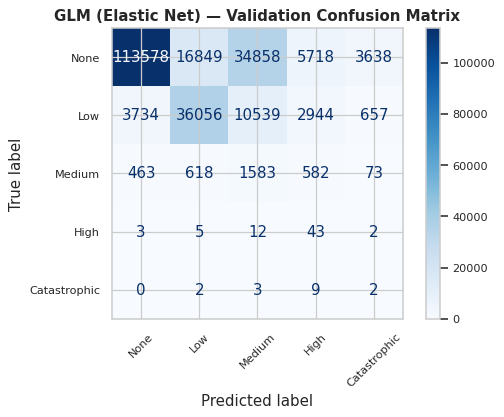

Top 10 positive coefficients for 'Catastrophic':
EVENT_TYPE_Debris Flow       3.955595
STATE_ABBREV_TN              1.145947
DAMAGE_CROPS_REPORTED        0.720056
CZ_TYPE_Z                    0.598054
EVENT_TYPE_Winter Weather    0.258566
STATE_ABBREV_MO              0.225637
STATE_ABBREV_MA              0.082085
EVENT_TYPE_Tornado           0.012376
STATE_ABBREV_KS              0.006959
EVENT_TYPE_Wildfire          0.000935
Name: Catastrophic, dtype: float64

Top 10 positive coefficients for 'None':
STATE_ABBREV_CO          3.265138
STATE_ABBREV_WA          1.993602
STATE_ABBREV_HI          1.564239
MAGNITUDE                1.314697
STATE_ABBREV_WV          1.226761
STATE_ABBREV_MT          1.148975
EVENT_TYPE_Hail          0.918527
EVENT_TYPE_Heavy Snow    0.910373
STATE_ABBREV_SD          0.807501
EVENT_TYPE_Flood         0.758333
Name: None, dtype: float64


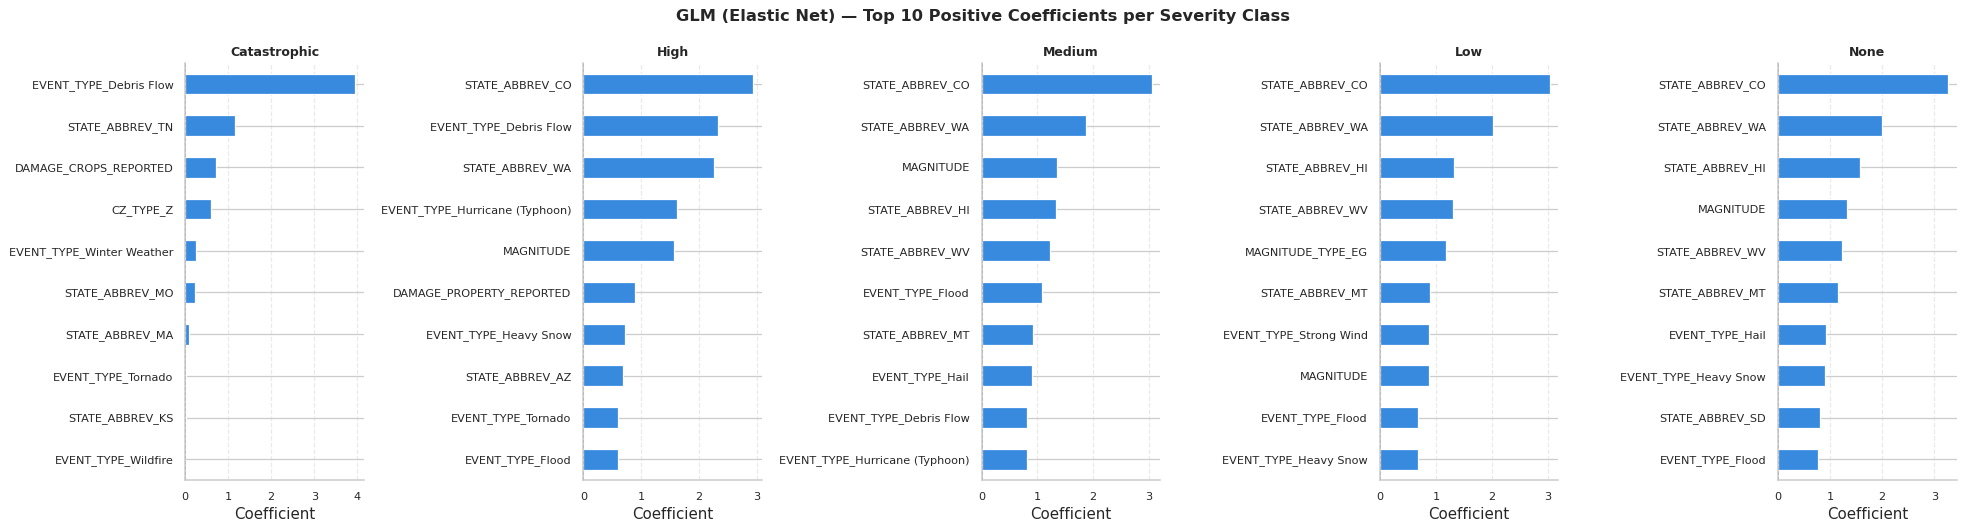


Tuned Elastic Net GLM — TEST performance:
              precision    recall  f1-score   support

        None       0.96      0.65      0.78    174641
         Low       0.67      0.67      0.67     53930
      Medium       0.03      0.48      0.06      3320
        High       0.00      0.67      0.01        66
Catastrophic       0.00      0.07      0.00        15

    accuracy                           0.65    231972
   macro avg       0.34      0.51      0.30    231972
weighted avg       0.88      0.65      0.74    231972


Macro F1 (test): 0.3040


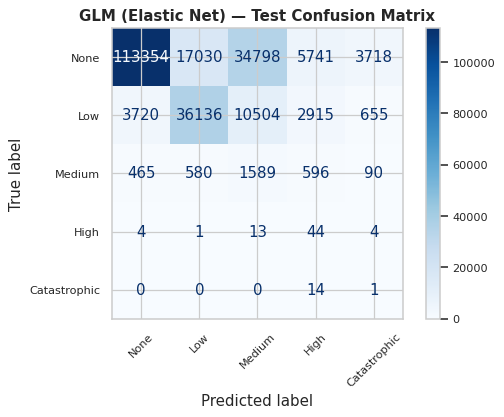


GLM aliases saved — tuned val F1 : 0.3042
GLM aliases saved — test F1      : 0.3040


In [5]:
CLASS_ORDER = ["None", "Low", "Medium", "High", "Catastrophic"]

# =============================================================================
# SECTION 1: Scale Features for GLM
# =============================================================================

scaler_glm  = StandardScaler()
X_train_glm = scaler_glm.fit_transform(X_train_final)
X_val_glm   = scaler_glm.transform(X_val_final)
X_test_glm  = scaler_glm.transform(X_test_final)

print(f"GLM training matrix: {X_train_glm.shape}")

# =============================================================================
# SECTION 2: Baseline GLM — No Penalty Tuning
# =============================================================================

baseline_glm = LogisticRegression(
    multi_class="multinomial",
    class_weight="balanced",
    max_iter=2000,
    random_state=6704
)

start = time.time()
print("Fitting baseline GLM...")
baseline_glm.fit(X_train_glm, y_train)
print(f"Done. Elapsed: {(time.time()-start)/60:.1f} minutes")

val_preds_baseline = np.array(baseline_glm.predict(X_val_glm)).astype(str)
print("\nBaseline GLM — Validation performance:")
print(classification_report(y_val, val_preds_baseline,
      labels=CLASS_ORDER, zero_division=0))
print(f"Macro F1 (val): {f1_score(y_val, val_preds_baseline, average='macro', zero_division=0):.4f}")

# =============================================================================
# SECTION 3: Tuned Elastic Net GLM — Fixed Parameters
# NOTE: Full LogisticRegressionCV (Cs=10, 5 l1_ratios, 5 folds = 250 fits)
# was computationally infeasible on available hardware. A single model with
# balanced L1/L2 penalty (l1_ratio=0.5, C=1.0) is used as the tuned variant.
# =============================================================================

glm_cv = LogisticRegression(
    multi_class="multinomial",
    solver="saga",
    penalty="elasticnet",
    l1_ratio=0.5,
    C=1.0,
    class_weight="balanced",
    max_iter=500,
    random_state=6704,
    n_jobs=-1
)

start = time.time()
print("\nFitting tuned Elastic Net GLM...")
glm_cv.fit(X_train_glm, y_train)
print(f"Done. Elapsed: {(time.time()-start)/60:.1f} minutes")

glm_cv.C_        = [glm_cv.C]
glm_cv.l1_ratio_ = [glm_cv.l1_ratio]

print(f"\nC (regularization)        : {glm_cv.C_}")
print(f"l1_ratio (L1/L2 balance)  : {glm_cv.l1_ratio_}")

# =============================================================================
# SECTION 4: Validation Evaluation — Tuned GLM
# =============================================================================

val_preds  = np.array(glm_cv.predict(X_val_glm)).astype(str)
test_preds = np.array(glm_cv.predict(X_test_glm)).astype(str)

print("\nTuned Elastic Net GLM — Validation performance:")
print(classification_report(y_val, val_preds,
      labels=CLASS_ORDER, zero_division=0))
print(f"Macro F1 (val): {f1_score(y_val, val_preds, average='macro', zero_division=0):.4f}")

cm   = confusion_matrix(y_val, val_preds, labels=CLASS_ORDER)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_ORDER)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("GLM (Elastic Net) — Validation Confusion Matrix", weight="bold")
plt.tight_layout()
plt.show()

# =============================================================================
# SECTION 5: Coefficient Inspection
# =============================================================================

coef_df = pd.DataFrame(
    glm_cv.coef_,
    columns=final_features_clean,
    index=glm_cv.classes_
)

print("Top 10 positive coefficients for 'Catastrophic':")
print(coef_df.loc["Catastrophic"].sort_values(ascending=False).head(10))

print("\nTop 10 positive coefficients for 'None':")
print(coef_df.loc["None"].sort_values(ascending=False).head(10))

# ── Coefficient Bar Chart — Top 10 per Class ─────────────────────────────────
focus_classes = ["Catastrophic", "High", "Medium", "Low", "None"]
fig, axes = plt.subplots(1, len(focus_classes), figsize=(22, 6), sharey=False)

for ax, cls in zip(axes, focus_classes):
    top_coefs = (
        coef_df.loc[cls]
        .sort_values(ascending=False)
        .head(10)
    )
    colors = ["#E05C2A" if v < 0 else "#378ADD" for v in top_coefs.values]
    top_coefs.plot(kind="barh", ax=ax, color=colors[::-1], edgecolor="white")
    ax.invert_yaxis()
    ax.set_title(f"{cls}", weight="bold", fontsize=10)
    ax.set_xlabel("Coefficient")
    ax.axvline(0, color="gray", linewidth=0.8, linestyle="--")
    ax.grid(axis="x", linestyle="--", alpha=0.4)

fig.suptitle("GLM (Elastic Net) — Top 10 Positive Coefficients per Severity Class",
             fontsize=13, weight="bold")
sns.despine()
plt.tight_layout()
plt.show()

# =============================================================================
# SECTION 6: Final Test Set Evaluation — Run Once
# =============================================================================

print("\nTuned Elastic Net GLM — TEST performance:")
print(classification_report(y_test, test_preds,
      labels=CLASS_ORDER, zero_division=0))
print(f"\nMacro F1 (test): {f1_score(y_test, test_preds, average='macro', zero_division=0):.4f}")

cm_test   = confusion_matrix(y_test, test_preds, labels=CLASS_ORDER)
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test,
                                    display_labels=CLASS_ORDER)
disp_test.plot(cmap="Blues", xticks_rotation=45)
plt.title("GLM (Elastic Net) — Test Confusion Matrix", weight="bold")
plt.tight_layout()
plt.show()

# =============================================================================
# ALIASES — for Master Results section
# =============================================================================
y_val_pred_glm_base   = val_preds_baseline.copy()
y_val_pred_glm_tuned  = val_preds.copy()
y_test_pred_glm_tuned = test_preds.copy()
print(f"\nGLM aliases saved — tuned val F1 : {f1_score(y_val, y_val_pred_glm_tuned, average='macro', zero_division=0):.4f}")
print(f"GLM aliases saved — test F1      : {f1_score(y_test, y_test_pred_glm_tuned, average='macro', zero_division=0):.4f}")

## Section 6: Random Forest

EXPERIMENT 1: Baseline RF — 50 Selected Features

Running stratified 5-fold CV...
CV F1 (macro) per fold : [0.3497 0.3512 0.3488 0.3487 0.3495]
Mean F1 (macro)        : 0.3496
Std                    : 0.0009

--- Validation Results ---
              precision    recall  f1-score   support

Catastrophic       0.00      0.38      0.00        16
        High       0.01      0.43      0.02        65
         Low       0.71      0.73      0.72     53930
      Medium       0.07      0.61      0.13      3319
        None       0.97      0.80      0.88    174641

    accuracy                           0.78    231971
   macro avg       0.35      0.59      0.35    231971
weighted avg       0.90      0.78      0.83    231971

Macro F1 (val): 0.3496

Top 20 Features by Gini Importance:
YEAR                              0.2088
EVENT_TYPE_Tornado                0.1363
MAGNITUDE                         0.1276
DAMAGE_PROPERTY_REPORTED          0.1013
MAGNITUDE_TYPE_EG                 0.0572
DAMAGE_CRO

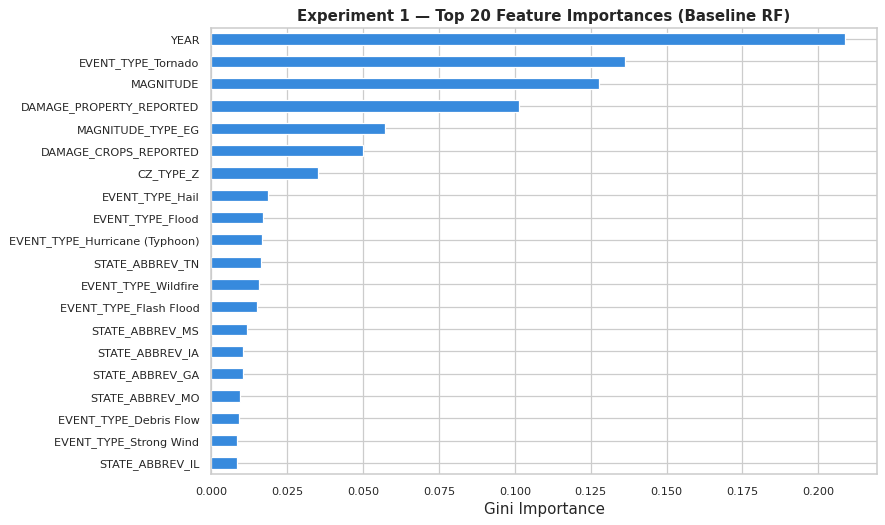


EXPERIMENT 2: RF Without YEAR — Temporal Artifact Check
Feature count without YEAR: 50

--- Validation Results ---
              precision    recall  f1-score   support

Catastrophic       0.00      0.44      0.00        16
        High       0.01      0.34      0.01        65
         Low       0.70      0.68      0.69     53930
      Medium       0.06      0.53      0.10      3319
        None       0.97      0.78      0.87    174641

    accuracy                           0.76    231971
   macro avg       0.35      0.55      0.34    231971
weighted avg       0.89      0.76      0.81    231971

Macro F1 (val): 0.3355

Top 20 Features (no YEAR):
EVENT_TYPE_Tornado                0.1838
MAGNITUDE                         0.1646
DAMAGE_PROPERTY_REPORTED          0.1308
MAGNITUDE_TYPE_EG                 0.0694
DAMAGE_CROPS_REPORTED             0.0679
CZ_TYPE_Z                         0.0453
EVENT_TYPE_Hail                   0.0237
EVENT_TYPE_Flood                  0.0215
EVENT_TYPE_Hurri

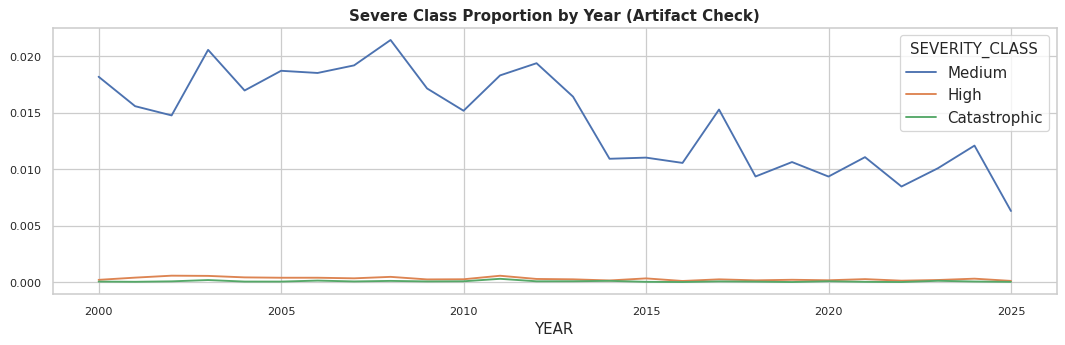


EXPERIMENT 3: RF With SMOTE Oversampling
Original training class counts:
SEVERITY_CLASS
None            814988
Low             251673
Medium           15492
High               307
Catastrophic        71
Name: count, dtype: int64

Original training shape: (1082531, 51)
After SMOTE shape      : (1092661, 51)

Class distribution after SMOTE:
SEVERITY_CLASS
None            814988
Low             251673
Medium           20000
High              5000
Catastrophic      1000
Name: count, dtype: int64

--- Validation Results ---
              precision    recall  f1-score   support

Catastrophic       0.00      0.00      0.00        16
        High       0.00      0.00      0.00        65
         Low       0.78      0.74      0.76     53930
      Medium       0.66      0.07      0.13      3319
        None       0.91      0.95      0.93    174641

    accuracy                           0.88    231971
   macro avg       0.47      0.35      0.36    231971
weighted avg       0.88      0.88      0

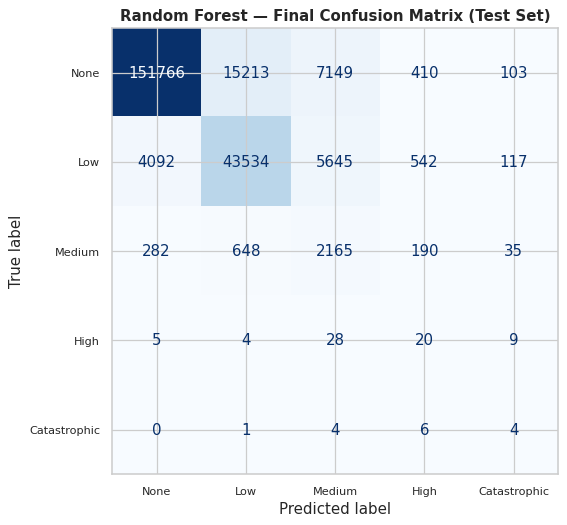

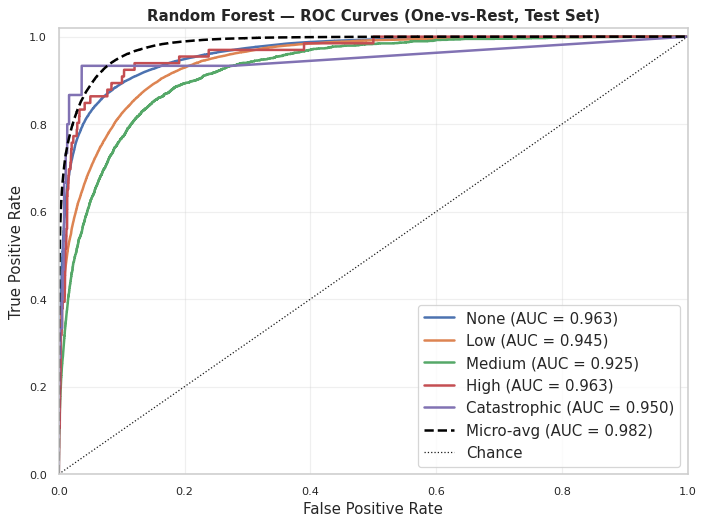

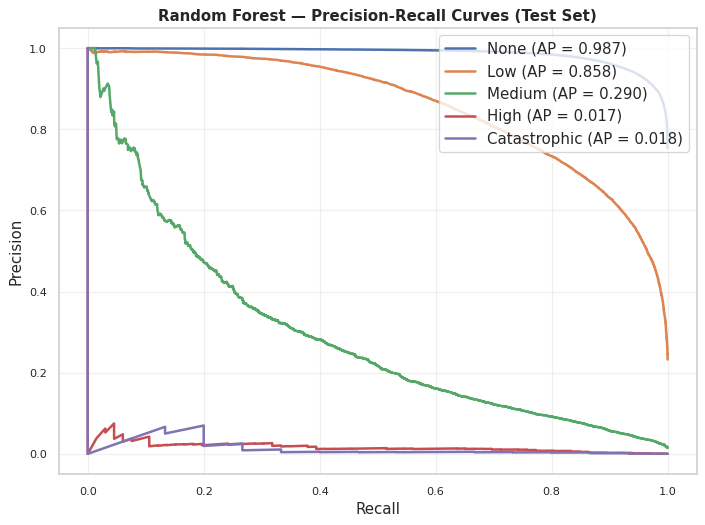


RF aliases saved — base val F1  : 0.3496
RF aliases saved — base test F1 : 0.3488
RF aliases saved — full val F1  : 0.3988
RF aliases saved — full test F1 : 0.3966

Final model saved to rf_final_model.pkl


In [14]:
# =============================================================================
# RANDOM FOREST — FULL EXPERIMENTAL PIPELINE
# STA6704 | Natural Disaster Severity Classification
# Author: Alejandro Arroyo
# =============================================================================

from sklearn.preprocessing import label_binarize
from sklearn.metrics import (roc_curve, auc, roc_auc_score,
                              precision_recall_curve, average_precision_score)

CLASS_ORDER = ["None", "Low", "Medium", "High", "Catastrophic"]

# =============================================================================
# EXPERIMENT 1: Baseline RF — 50 Selected Features
# =============================================================================
print("=" * 70)
print("EXPERIMENT 1: Baseline RF — 50 Selected Features")
print("=" * 70)

rf_baseline = RandomForestClassifier(
    n_estimators=500,
    class_weight="balanced",
    random_state=6704,
    n_jobs=-1,
    min_samples_leaf=5
)

print("\nRunning stratified 5-fold CV...")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=6704)
cv_scores = cross_val_score(
    rf_baseline, X_train_final, y_train,
    cv=cv, scoring="f1_macro", n_jobs=-1
)
print(f"CV F1 (macro) per fold : {cv_scores.round(4)}")
print(f"Mean F1 (macro)        : {cv_scores.mean():.4f}")
print(f"Std                    : {cv_scores.std():.4f}")

rf_baseline.fit(X_train_final, y_train)
y_val_pred_baseline = rf_baseline.predict(X_val_final)

print("\n--- Validation Results ---")
print(classification_report(y_val, y_val_pred_baseline,
      target_names=["Catastrophic", "High", "Low", "Medium", "None"]))
print(f"Macro F1 (val): {f1_score(y_val, y_val_pred_baseline, average='macro'):.4f}")

importance_baseline = pd.Series(
    rf_baseline.feature_importances_, index=final_features_clean
).sort_values(ascending=False)
print("\nTop 20 Features by Gini Importance:")
print(importance_baseline.head(20).round(4).to_string())

fig, ax = plt.subplots(figsize=(10, 6))
importance_baseline.head(20).plot(kind="barh", ax=ax, color="#378ADD")
ax.invert_yaxis()
ax.set_xlabel("Gini Importance")
ax.set_title("Experiment 1 — Top 20 Feature Importances (Baseline RF)", weight="bold")
plt.tight_layout()
plt.show()

# =============================================================================
# EXPERIMENT 2: RF Without YEAR — Temporal Artifact Check
# =============================================================================
print("\n" + "=" * 70)
print("EXPERIMENT 2: RF Without YEAR — Temporal Artifact Check")
print("=" * 70)

features_no_year = [f for f in final_features_clean if f != "YEAR"]
print(f"Feature count without YEAR: {len(features_no_year)}")

rf_no_year = RandomForestClassifier(
    n_estimators=500,
    class_weight="balanced",
    random_state=6704,
    n_jobs=-1,
    min_samples_leaf=5
)
rf_no_year.fit(X_train_final[features_no_year], y_train)
y_val_pred_no_year = rf_no_year.predict(X_val_final[features_no_year])

print("\n--- Validation Results ---")
print(classification_report(y_val, y_val_pred_no_year,
      target_names=["Catastrophic", "High", "Low", "Medium", "None"]))
print(f"Macro F1 (val): {f1_score(y_val, y_val_pred_no_year, average='macro'):.4f}")

importance_no_year = pd.Series(
    rf_no_year.feature_importances_, index=features_no_year
).sort_values(ascending=False)
print("\nTop 20 Features (no YEAR):")
print(importance_no_year.head(20).round(4).to_string())

# ── YEAR artifact check ───────────────────────────────────────────────────────
year_severity = final_df.groupby("YEAR")["SEVERITY_CLASS"].value_counts(
    normalize=True).unstack().fillna(0)
year_severity[["Medium", "High", "Catastrophic"]].plot(
    figsize=(12, 4),
    title="Severe Class Proportion by Year (Artifact Check)"
)
plt.tight_layout()
plt.show()

# =============================================================================
# EXPERIMENT 3: RF With SMOTE Oversampling
# =============================================================================
print("\n" + "=" * 70)
print("EXPERIMENT 3: RF With SMOTE Oversampling")
print("=" * 70)

print("Original training class counts:")
print(y_train.value_counts())

smote = SMOTE(
    sampling_strategy={"High": 5000, "Catastrophic": 1000, "Medium": 20000},
    random_state=6704,
    k_neighbors=3
)
X_train_sm, y_train_sm = smote.fit_resample(X_train_final, y_train)

print(f"\nOriginal training shape: {X_train_final.shape}")
print(f"After SMOTE shape      : {X_train_sm.shape}")
print(f"\nClass distribution after SMOTE:")
print(pd.Series(y_train_sm).value_counts())

rf_smote = RandomForestClassifier(
    n_estimators=500,
    random_state=6704,
    n_jobs=-1,
    min_samples_leaf=5
)
rf_smote.fit(X_train_sm, y_train_sm)
y_val_pred_smote = rf_smote.predict(X_val_final)

print("\n--- Validation Results ---")
print(classification_report(y_val, y_val_pred_smote,
      target_names=["Catastrophic", "High", "Low", "Medium", "None"]))
print(f"Macro F1 (val): {f1_score(y_val, y_val_pred_smote, average='macro'):.4f}")

# =============================================================================
# EXPERIMENT 4: RF With Full Feature Set (109 features)
# =============================================================================
print("\n" + "=" * 70)
print("EXPERIMENT 4: RF — Full Feature Set (Pre-Selection, 109 Features)")
print("=" * 70)

leakage_cols = [
    "EVENT_ID",
    "DEATHS_TOTAL", "DEATHS_DIRECT", "DEATHS_INDIRECT",
    "INJURIES_DIRECT", "INJURIES_INDIRECT",
    "DAMAGE_CROPS_USD", "DAMAGE_PROPERTY_USD", "DAMAGE_TOTAL_USD",
    "DAMAGE_TOTAL_USD_REPORTED", "DAMAGE_SCORE", "DEATH_SCORE",
    "INJURY_SCORE", "SEVERITY_COMPOSITE"
]
full_features = [c for c in X_train_enc.columns if c not in leakage_cols]
print(f"Full feature count: {len(full_features)}")

X_train_full = X_train_enc[full_features]
X_val_full   = X_val_enc[full_features]
X_test_full  = X_test_enc[full_features]

rf_full = RandomForestClassifier(
    n_estimators=500,
    class_weight="balanced",
    random_state=6704,
    n_jobs=-1,
    min_samples_leaf=5
)
rf_full.fit(X_train_full, y_train)
y_val_pred_full = rf_full.predict(X_val_full)

print("\n--- Validation Results ---")
print(classification_report(y_val, y_val_pred_full,
      target_names=["Catastrophic", "High", "Low", "Medium", "None"]))
print(f"Macro F1 (val): {f1_score(y_val, y_val_pred_full, average='macro'):.4f}")

importance_full = pd.Series(
    rf_full.feature_importances_, index=full_features
).sort_values(ascending=False)
print("\nTop 20 Features (full set):")
print(importance_full.head(20).round(4).to_string())

# =============================================================================
# EXPERIMENT COMPARISON SUMMARY
# =============================================================================
print("\n" + "=" * 70)
print("EXPERIMENT COMPARISON SUMMARY")
print("=" * 70)

rf_comparison = pd.DataFrame({
    "Experiment": [
        "1. Baseline RF (50 features, balanced)",
        "2. RF without YEAR (49 features)",
        "3. RF with SMOTE (50 features)",
        "4. RF full feature set (109 features)"
    ],
    "Val_Macro_F1": [
        f1_score(y_val, y_val_pred_baseline, average="macro"),
        f1_score(y_val, y_val_pred_no_year,  average="macro"),
        f1_score(y_val, y_val_pred_smote,    average="macro"),
        f1_score(y_val, y_val_pred_full,     average="macro"),
    ]
})
rf_comparison["Val_Macro_F1"] = rf_comparison["Val_Macro_F1"].round(4)
print(rf_comparison.to_string(index=False))

best_rf_experiment = rf_comparison.loc[rf_comparison["Val_Macro_F1"].idxmax(), "Experiment"]
print(f"\nBest performing experiment: {best_rf_experiment}")

# =============================================================================
# FINAL MODEL — Test Set Evaluation (best model = rf_full, 109 features)
# FIX: use rf_full on X_test_full, not rf_baseline on X_test_final
# =============================================================================
print("\n" + "=" * 70)
print("FINAL MODEL — Test Set Evaluation")
print("=" * 70)

y_test_pred_final = rf_full.predict(X_test_full)

print("\n--- Final Test Set Results ---")
print(classification_report(y_test, y_test_pred_final,
      target_names=["Catastrophic", "High", "Low", "Medium", "None"]))
print(f"Macro F1 (test): {f1_score(y_test, y_test_pred_final, average='macro'):.4f}")

# ── Confusion Matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_test_pred_final,
     labels=["None", "Low", "Medium", "High", "Catastrophic"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
       display_labels=["None", "Low", "Medium", "High", "Catastrophic"])
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Random Forest — Final Confusion Matrix (Test Set)", weight="bold")
plt.tight_layout()
plt.show()

# ── ROC Curves ────────────────────────────────────────────────────────────────
le_rf         = LabelEncoder().fit(CLASS_ORDER)
y_test_enc_rf = le_rf.transform(y_test)
y_proba_rf    = rf_full.predict_proba(X_test_full)
y_bin_rf      = label_binarize(y_test_enc_rf,
                classes=list(range(len(CLASS_ORDER))))
present_rf    = np.unique(y_test_enc_rf)

plt.figure(figsize=(8, 6))
for cls in CLASS_ORDER:
    i = le_rf.transform([cls])[0]
    if y_bin_rf[:, i].sum() == 0:
        continue
    fpr, tpr, _ = roc_curve(y_bin_rf[:, i], y_proba_rf[:, i])
    plt.plot(fpr, tpr, lw=2, label=f"{cls} (AUC = {auc(fpr, tpr):.3f})")

fpr_m, tpr_m, _ = roc_curve(
    y_bin_rf[:, present_rf].ravel(),
    y_proba_rf[:, present_rf].ravel()
)
plt.plot(fpr_m, tpr_m, lw=2, ls="--", color="black",
         label=f"Micro-avg (AUC = {auc(fpr_m, tpr_m):.3f})")
plt.plot([0, 1], [0, 1], "k:", lw=1, label="Chance")
plt.xlim(0, 1); plt.ylim(0, 1.02)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest — ROC Curves (One-vs-Rest, Test Set)", weight="bold")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ── Precision-Recall Curves ───────────────────────────────────────────────────
plt.figure(figsize=(8, 6))
for cls in CLASS_ORDER:
    i = le_rf.transform([cls])[0]
    if y_bin_rf[:, i].sum() == 0:
        continue
    precision, recall, _ = precision_recall_curve(y_bin_rf[:, i], y_proba_rf[:, i])
    ap = average_precision_score(y_bin_rf[:, i], y_proba_rf[:, i])
    plt.plot(recall, precision, lw=2, label=f"{cls} (AP = {ap:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Random Forest — Precision-Recall Curves (Test Set)", weight="bold")
plt.legend(loc="upper right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# =============================================================================
# ALIASES — for Master Results section
# =============================================================================
y_val_pred_rf_baseline  = np.array(y_val_pred_baseline).astype(str)
y_val_pred_rf_full      = np.array(y_val_pred_full).astype(str)
y_test_pred_rf_baseline = np.array(rf_baseline.predict(X_test_final)).astype(str)
y_test_pred_rf_final    = np.array(y_test_pred_final).astype(str)
y_val_pred_no_year      = np.array(y_val_pred_no_year).astype(str)
y_val_pred_smote        = np.array(y_val_pred_smote).astype(str)

print(f"\nRF aliases saved — base val F1  : {f1_score(y_val,  y_val_pred_rf_baseline,  average='macro', zero_division=0):.4f}")
print(f"RF aliases saved — base test F1 : {f1_score(y_test, y_test_pred_rf_baseline, average='macro', zero_division=0):.4f}")
print(f"RF aliases saved — full val F1  : {f1_score(y_val,  y_val_pred_rf_full,      average='macro', zero_division=0):.4f}")
print(f"RF aliases saved — full test F1 : {f1_score(y_test, y_test_pred_rf_final,    average='macro', zero_division=0):.4f}")

joblib.dump(rf_full, "rf_final_model.pkl")
print("\nFinal model saved to rf_final_model.pkl")

## Section 7: SVM

Label mapping: {'Catastrophic': np.int64(0), 'High': np.int64(1), 'Low': np.int64(2), 'Medium': np.int64(3), 'None': np.int64(4)}
None encoded as: 4

Preprocessing features...
X_train_proc shape : (1082531, 112)
X_val_proc shape   : (231971, 112)
X_test_proc shape  : (231972, 112)

Class distribution in train:
SEVERITY_CLASS
None            814988
Low             251673
Medium           15492
High               307
Catastrophic        71
Name: count, dtype: int64

Setup complete. Running SVM experiments...

SVM EXPERIMENT 1: LinearSVC — Full Training Set
Fitting LinearSVC on full training set...
Done. Elapsed: 3.6 minutes

--- Validation Results ---
              precision    recall  f1-score   support

Catastrophic       0.00      0.00      0.00        16
        High       0.00      0.00      0.00        65
         Low       0.67      0.53      0.59     53930
      Medium       0.36      0.02      0.04      3319
        None       0.85      0.92      0.89    174641

    accuracy    

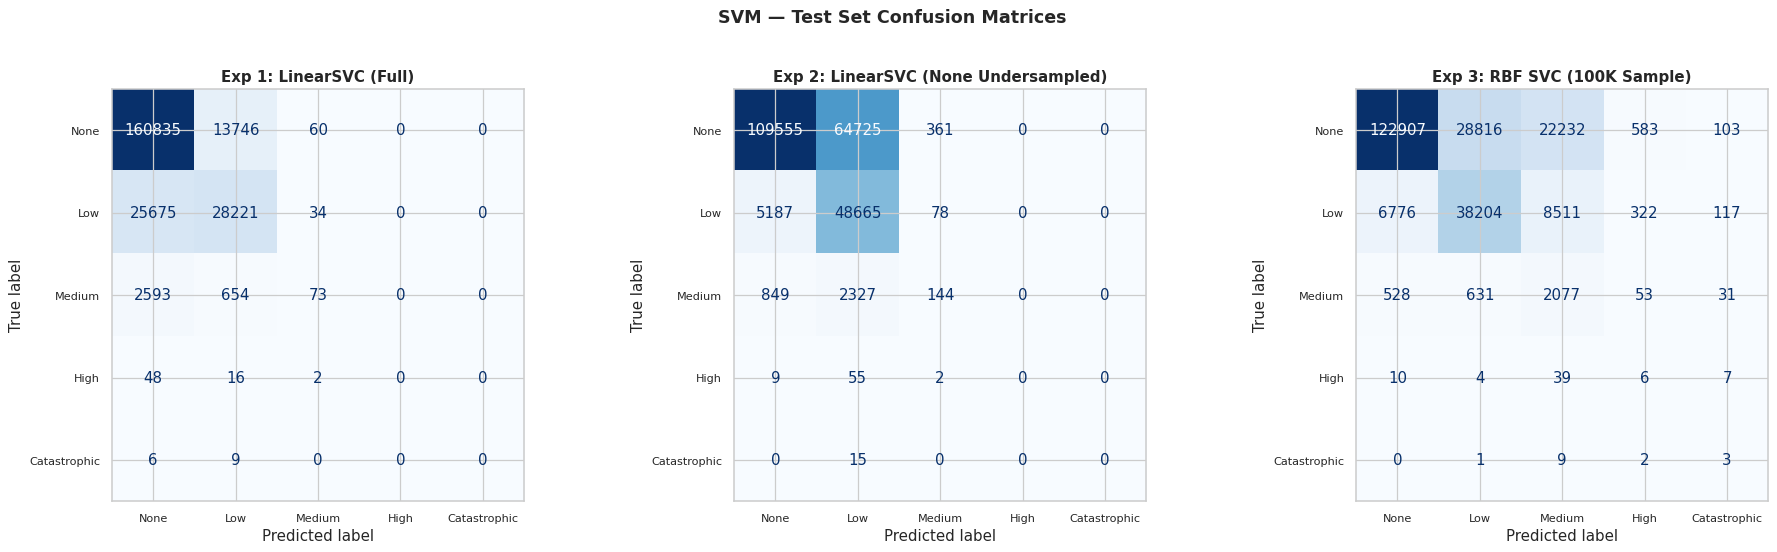


SVM EXPERIMENT COMPARISON SUMMARY
                                  Experiment  Val_Macro_F1  Test_Macro_F1
                     Exp 1: LinearSVC (Full)        0.3018         0.3021
Exp 2: LinearSVC (None undersampled to 100K)        0.2796         0.2804
     Exp 3: RBF SVC (100K stratified sample)        0.3124         0.3166

Best SVM experiment: Exp 3: RBF SVC (100K stratified sample)
Val Macro F1: 0.3124 | Test Macro F1: 0.3166

Saved: svc_linear_full.pkl, svc_linear_undersampled.pkl, svc_rbf_100k.pkl


In [7]:
# =============================================================================
# SETUP — Self-contained, run after any kernel restart
# =============================================================================
RANDOM_STATE = 6704

numeric_cols     = ["MAGNITUDE", "YEAR", "MONTH"]
categorical_cols = ["STATE_ABBREV", "EVENT_TYPE", "CZ_TYPE", "MAGNITUDE_TYPE"]

for col in numeric_cols:
    if col in final_df.columns:
        final_df[col] = pd.to_numeric(final_df[col], errors="coerce")

drop_cols = [
    "SEVERITY_CLASS", "SEVERITY_COMPOSITE",
    "DEATH_SCORE", "INJURY_SCORE", "DAMAGE_SCORE",
    "DEATHS_DIRECT", "DEATHS_INDIRECT", "DEATHS_TOTAL",
    "INJURIES_DIRECT", "INJURIES_INDIRECT",
    "DAMAGE_PROPERTY_USD", "DAMAGE_CROPS_USD",
    "DAMAGE_TOTAL_USD", "DAMAGE_TOTAL_USD_REPORTED",
    "EVENT_ID", "STATE", "SOURCE", "DATA_SOURCE", "COUNTRY",
    "BEGIN_DATE", "CZ_NAME",
    "DAMAGE_CROPS_REPORTED", "DAMAGE_PROPERTY_REPORTED",
    "MAGNITUDE_APPLICABLE", "LOCATION_PRECISE",
]

X = final_df.drop(columns=[c for c in drop_cols if c in final_df.columns])
y = final_df["SEVERITY_CLASS"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=RANDOM_STATE
)

le = LabelEncoder()
le.fit(y_train)

y_train_enc = le.transform(y_train)
y_val_enc   = le.transform(y_val)
y_test_enc  = le.transform(y_test)

NONE_LABEL = le.transform(["None"])[0]
print(f"Label mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}")
print(f"None encoded as: {NONE_LABEL}")

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_pipeline,     numeric_cols),
    ("cat", categorical_pipeline, categorical_cols)
], remainder="drop")

print("\nPreprocessing features...")
X_train_proc = preprocessor.fit_transform(X_train)
X_val_proc   = preprocessor.transform(X_val)
X_test_proc  = preprocessor.transform(X_test)

print(f"X_train_proc shape : {X_train_proc.shape}")
print(f"X_val_proc shape   : {X_val_proc.shape}")
print(f"X_test_proc shape  : {X_test_proc.shape}")
print(f"\nClass distribution in train:")
print(y_train.value_counts())
print("\nSetup complete. Running SVM experiments...")

# =============================================================================
# EXPERIMENT 1: LinearSVC — Full Training Set
# =============================================================================
print("\n" + "=" * 70)
print("SVM EXPERIMENT 1: LinearSVC — Full Training Set")
print("=" * 70)

linear_svc_full = LinearSVC(
    C=1.0, class_weight="balanced",
    random_state=RANDOM_STATE, max_iter=2000
)
svc_linear_full = CalibratedClassifierCV(linear_svc_full, cv=3)

print("Fitting LinearSVC on full training set...")
start = time.time()
svc_linear_full.fit(X_train_proc, y_train_enc)
print(f"Done. Elapsed: {(time.time()-start)/60:.1f} minutes")

y_val_pred_lf_enc  = svc_linear_full.predict(X_val_proc)
y_val_pred_lf      = le.inverse_transform(y_val_pred_lf_enc)
y_test_pred_lf_enc = svc_linear_full.predict(X_test_proc)
y_test_pred_lf     = le.inverse_transform(y_test_pred_lf_enc)

print("\n--- Validation Results ---")
print(classification_report(y_val, y_val_pred_lf,
      target_names=["Catastrophic", "High", "Low", "Medium", "None"],
      zero_division=0))
print(f"Macro F1 (val): {f1_score(y_val, y_val_pred_lf, average='macro'):.4f}")

print("\n--- Test Results ---")
print(classification_report(y_test, y_test_pred_lf,
      target_names=["Catastrophic", "High", "Low", "Medium", "None"],
      zero_division=0))
print(f"Macro F1 (test): {f1_score(y_test, y_test_pred_lf, average='macro'):.4f}")

# =============================================================================
# EXPERIMENT 2: LinearSVC — None Undersampled to 100K
# =============================================================================
print("\n" + "=" * 70)
print("SVM EXPERIMENT 2: LinearSVC — None Undersampled to 100K")
print("=" * 70)

rus = RandomUnderSampler(
    sampling_strategy={NONE_LABEL: 100_000},
    random_state=RANDOM_STATE
)
X_train_us, y_train_us = rus.fit_resample(X_train_proc, y_train_enc)

print(f"Original training shape : {X_train_proc.shape}")
print(f"Undersampled shape      : {X_train_us.shape}")
print(f"\nClass distribution after undersampling:")
print(pd.Series(le.inverse_transform(y_train_us)).value_counts())

linear_svc_us = LinearSVC(
    C=1.0, class_weight="balanced",
    random_state=RANDOM_STATE, max_iter=2000
)
svc_linear_us = CalibratedClassifierCV(linear_svc_us, cv=3)

print("\nFitting LinearSVC on undersampled training set...")
start = time.time()
svc_linear_us.fit(X_train_us, y_train_us)
print(f"Done. Elapsed: {(time.time()-start)/60:.1f} minutes")

y_val_pred_lu_enc  = svc_linear_us.predict(X_val_proc)
y_val_pred_lu      = le.inverse_transform(y_val_pred_lu_enc)
y_test_pred_lu_enc = svc_linear_us.predict(X_test_proc)
y_test_pred_lu     = le.inverse_transform(y_test_pred_lu_enc)

print("\n--- Validation Results ---")
print(classification_report(y_val, y_val_pred_lu,
      target_names=["Catastrophic", "High", "Low", "Medium", "None"],
      zero_division=0))
print(f"Macro F1 (val): {f1_score(y_val, y_val_pred_lu, average='macro'):.4f}")

print("\n--- Test Results ---")
print(classification_report(y_test, y_test_pred_lu,
      target_names=["Catastrophic", "High", "Low", "Medium", "None"],
      zero_division=0))
print(f"Macro F1 (test): {f1_score(y_test, y_test_pred_lu, average='macro'):.4f}")

# =============================================================================
# EXPERIMENT 3: RBF SVC — 100K Stratified Sample
# =============================================================================
print("\n" + "=" * 70)
print("SVM EXPERIMENT 3: RBF SVC — 100K Stratified Sample")
print("=" * 70)

sss_rbf = StratifiedShuffleSplit(
    n_splits=1,
    test_size=1 - 100_000 / len(X_train_proc),
    random_state=RANDOM_STATE
)
rbf_idx, _ = next(sss_rbf.split(X_train_proc, y_train_enc))

X_rbf_sample = X_train_proc[rbf_idx]
y_rbf_sample = y_train_enc[rbf_idx]

print(f"RBF training sample: {len(X_rbf_sample):,} rows")
print(f"Class distribution:")
print(pd.Series(le.inverse_transform(y_rbf_sample)).value_counts())

svc_rbf_sample = SVC(
    kernel="rbf", C=1.0, gamma="scale",
    class_weight="balanced", random_state=RANDOM_STATE
)

print("\nFitting RBF SVC on 100K sample...")
start = time.time()
svc_rbf_sample.fit(X_rbf_sample, y_rbf_sample)
print(f"Done. Elapsed: {(time.time()-start)/60:.1f} minutes")

y_val_pred_rs_enc  = svc_rbf_sample.predict(X_val_proc)
y_val_pred_rs      = le.inverse_transform(y_val_pred_rs_enc)
y_test_pred_rs_enc = svc_rbf_sample.predict(X_test_proc)
y_test_pred_rs     = le.inverse_transform(y_test_pred_rs_enc)

print("\n--- Validation Results ---")
print(classification_report(y_val, y_val_pred_rs,
      target_names=["Catastrophic", "High", "Low", "Medium", "None"],
      zero_division=0))
print(f"Macro F1 (val): {f1_score(y_val, y_val_pred_rs, average='macro'):.4f}")

print("\n--- Test Results ---")
print(classification_report(y_test, y_test_pred_rs,
      target_names=["Catastrophic", "High", "Low", "Medium", "None"],
      zero_division=0))
print(f"Macro F1 (test): {f1_score(y_test, y_test_pred_rs, average='macro'):.4f}")

# =============================================================================
# CONFUSION MATRICES — 1x3 Grid (Test Set)
# =============================================================================
CLASS_LABELS = ["None", "Low", "Medium", "High", "Catastrophic"]

fig, axes = plt.subplots(1, 3, figsize=(21, 6))

for ax, (preds, title) in zip(axes, [
    (y_test_pred_lf, "Exp 1: LinearSVC (Full)"),
    (y_test_pred_lu, "Exp 2: LinearSVC (None Undersampled)"),
    (y_test_pred_rs, "Exp 3: RBF SVC (100K Sample)"),
]):
    cm = confusion_matrix(y_test, preds, labels=CLASS_LABELS)
    ConfusionMatrixDisplay(confusion_matrix=cm,
           display_labels=CLASS_LABELS).plot(
           ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(title, weight="bold")

plt.suptitle("SVM — Test Set Confusion Matrices", fontsize=14, weight="bold", y=1.02)
plt.tight_layout()
plt.show()

# =============================================================================
# SVM EXPERIMENT COMPARISON SUMMARY
# =============================================================================
print("\n" + "=" * 70)
print("SVM EXPERIMENT COMPARISON SUMMARY")
print("=" * 70)

svm_results = pd.DataFrame({
    "Experiment": [
        "Exp 1: LinearSVC (Full)",
        "Exp 2: LinearSVC (None undersampled to 100K)",
        "Exp 3: RBF SVC (100K stratified sample)",
    ],
    "Val_Macro_F1": [
        f1_score(y_val, y_val_pred_lf, average="macro"),
        f1_score(y_val, y_val_pred_lu, average="macro"),
        f1_score(y_val, y_val_pred_rs, average="macro"),
    ],
    "Test_Macro_F1": [
        f1_score(y_test, y_test_pred_lf, average="macro"),
        f1_score(y_test, y_test_pred_lu, average="macro"),
        f1_score(y_test, y_test_pred_rs, average="macro"),
    ]
})

svm_results["Val_Macro_F1"]  = svm_results["Val_Macro_F1"].round(4)
svm_results["Test_Macro_F1"] = svm_results["Test_Macro_F1"].round(4)
print(svm_results.to_string(index=False))

best_row = svm_results.loc[svm_results["Val_Macro_F1"].idxmax()]
print(f"\nBest SVM experiment: {best_row['Experiment']}")
print(f"Val Macro F1: {best_row['Val_Macro_F1']} | Test Macro F1: {best_row['Test_Macro_F1']}")

# =============================================================================
# SAVE COMPLETED MODELS
# =============================================================================
import joblib
joblib.dump(svc_linear_full,  "svc_linear_full.pkl")
joblib.dump(svc_linear_us,    "svc_linear_undersampled.pkl")
joblib.dump(svc_rbf_sample,   "svc_rbf_100k.pkl")
print("\nSaved: svc_linear_full.pkl, svc_linear_undersampled.pkl, svc_rbf_100k.pkl")

## Section 8: XGBoost

xgboost version : 3.3.0
Label mapping   : {np.str_('Catastrophic'): 0, np.str_('High'): 1, np.str_('Low'): 2, np.str_('Medium'): 3, np.str_('None'): 4}
Train/Val/Test  : (1082531, 51) / (231971, 51) / (231972, 51)

Training class counts:
SEVERITY_CLASS
None            814988
Low             251673
Medium           15492
High               307
Catastrophic        71
EXPERIMENT 1: Baseline XGBoost
Best iteration (early stopping): 36

--- Baseline XGBoost — Validation ---
              precision    recall  f1-score   support

Catastrophic     0.0025    0.3750    0.0049        16
        High     0.0074    0.3846    0.0144        65
         Low     0.6858    0.6707    0.6782     53930
      Medium     0.0508    0.5945    0.0935      3319
        None     0.9684    0.7461    0.8429    174641

    accuracy                         0.7263    231971
   macro avg     0.3430    0.5542    0.3268    231971
weighted avg     0.8893    0.7263    0.7936    231971

Macro F1 (val)         : 0.3268
Balan

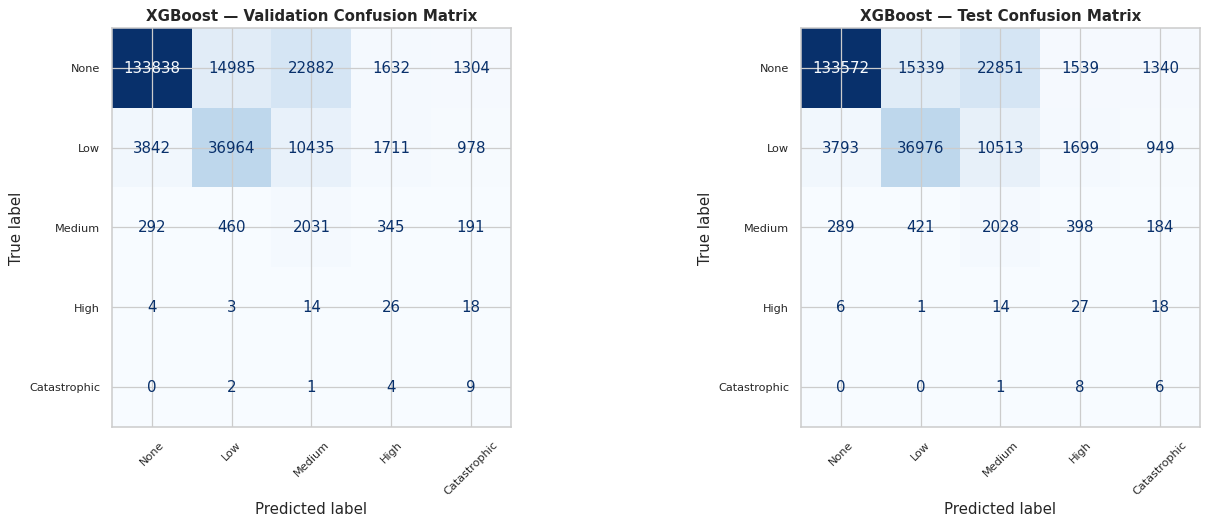


Test confusion matrix (row-normalised):
               None    Low  Medium   High  Catastrophic
None          0.765  0.088   0.131  0.009         0.008
Low           0.070  0.686   0.195  0.032         0.018
Medium        0.087  0.127   0.611  0.120         0.055
High          0.091  0.015   0.212  0.409         0.273
Catastrophic  0.000  0.000   0.067  0.533         0.400


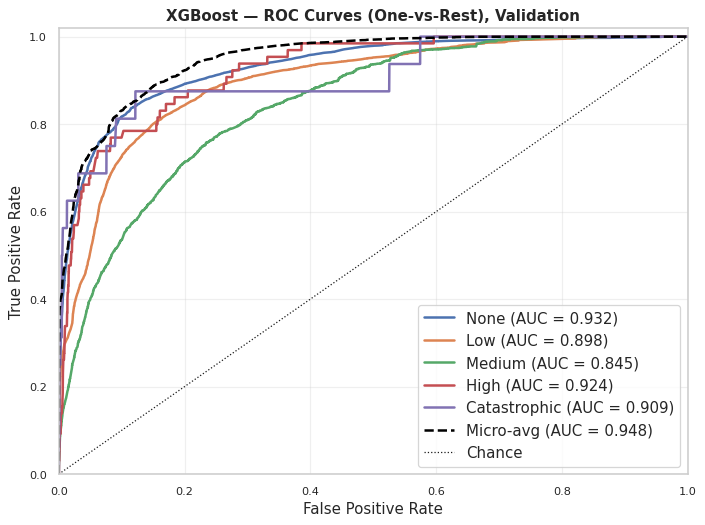

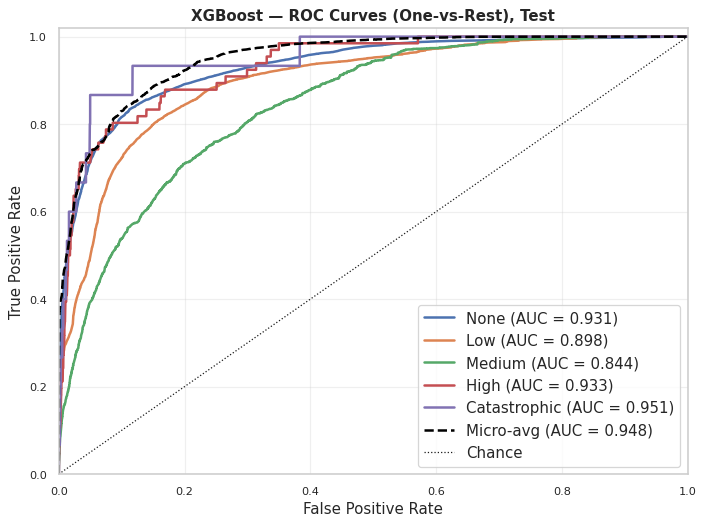

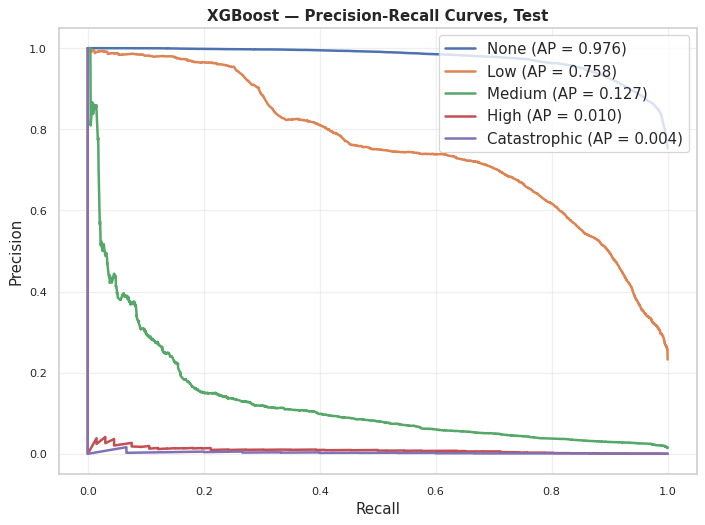

Top 20 features — XGBoost normalised importance:
EVENT_TYPE_Tornado                0.4189
DAMAGE_PROPERTY_REPORTED          0.0510
MAGNITUDE_TYPE_EG                 0.0491
EVENT_TYPE_Debris Flow            0.0393
EVENT_TYPE_Hurricane (Typhoon)    0.0384
EVENT_TYPE_Hail                   0.0270
EVENT_TYPE_Flood                  0.0255
EVENT_TYPE_Wildfire               0.0215
EVENT_TYPE_Flash Flood            0.0214
CZ_TYPE_Z                         0.0172
EVENT_TYPE_Funnel Cloud           0.0170
EVENT_TYPE_Lightning              0.0163
EVENT_TYPE_Storm Surge/Tide       0.0153
EVENT_TYPE_Tropical Storm         0.0147
EVENT_TYPE_Strong Wind            0.0146
EVENT_TYPE_Heavy Rain             0.0123
STATE_ABBREV_VT                   0.0123
MAGNITUDE                         0.0113
EVENT_TYPE_Ice Storm              0.0110
DAMAGE_CROPS_REPORTED             0.0101

Top 10 features by average gain:
EVENT_TYPE_Tornado                12795.22
DAMAGE_PROPERTY_REPORTED           1556.28
MAGNITUDE_T

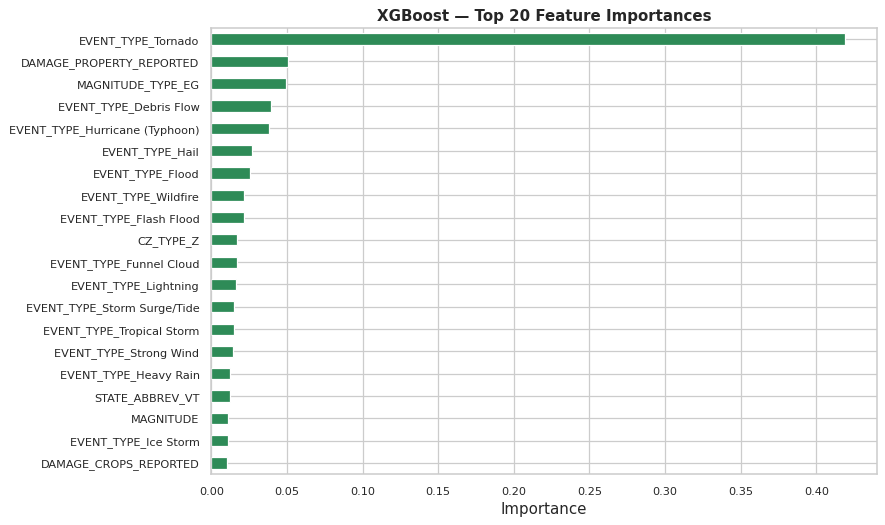

XGBOOST — FINAL RESULTS SUMMARY
Best configuration : {'max_depth': 10, 'learning_rate': 0.05, 'min_child_weight': 20, 'subsample': 0.9, 'colsample_bytree': 0.7, 'reg_lambda': 5.0, 'reg_alpha': 0.5}
Boosting rounds    : 73
Features used      : 51
CV macro F1 (train): 0.3353 (+/- 0.0007)
CV ROC AUC (train) : 0.9101 (+/- 0.0029)

Split                   Validation    Test
Accuracy                    0.7452  0.7441
Balanced Accuracy           0.6052  0.5741
Precision (macro)           0.3487  0.3477
Recall (macro)              0.6052  0.5741
F1 (macro)                  0.3355  0.3345
Precision (weighted)        0.8951  0.8943
Recall (weighted)           0.7452  0.7441
F1 (weighted)               0.8078  0.8067
Cohen's Kappa               0.4879  0.4863
MCC                         0.5215  0.5202
Log Loss                    0.6928  0.6948
ROC AUC (OvR macro)         0.9015  0.9113
ROC AUC (OvR weighted)      0.9225  0.9222
ROC AUC (OvO macro)         0.8536  0.8588
PR AUC (macro)            

In [8]:
RANDOM_STATE = 6704
CLASS_ORDER  = ["None", "Low", "Medium", "High", "Catastrophic"]

# =============================================================================
# SECTION 1: Setup — Labels, Encodings, Feature Matrices
# =============================================================================

y_train_xgb = y_train.loc[X_train_final.index]
y_val_xgb   = y_val.loc[X_val_final.index]
y_test_xgb  = y_test.loc[X_test_final.index]

le        = LabelEncoder().fit(CLASS_ORDER)
CLASSES   = list(le.classes_)
N_CLASSES = len(CLASSES)

y_train_enc = le.transform(y_train_xgb)
y_val_enc   = le.transform(y_val_xgb)
y_test_enc  = le.transform(y_test_xgb)

X_train_xgb = X_train_final.astype("float32")
X_val_xgb   = X_val_final.astype("float32")
X_test_xgb  = X_test_final.astype("float32")

w_train = compute_sample_weight(class_weight="balanced", y=y_train_enc)
w_val   = compute_sample_weight(class_weight="balanced", y=y_val_enc)

print(f"xgboost version : {xgb.__version__}")
print(f"Label mapping   : {dict(zip(CLASSES, [int(i) for i in le.transform(CLASSES)]))}")
print(f"Train/Val/Test  : {X_train_xgb.shape} / {X_val_xgb.shape} / {X_test_xgb.shape}")
print("\nTraining class counts:")
print(pd.Series(y_train_xgb).value_counts().reindex(CLASS_ORDER).to_string())

# =============================================================================
# SECTION 2: Shared Helpers
# =============================================================================

XGB_BASE_PARAMS = dict(
    objective    = "multi:softprob",
    eval_metric  = "mlogloss",
    tree_method  = "hist",
    random_state = RANDOM_STATE,
    n_jobs       = -1,
)

def build_xgb(**overrides):
    params = dict(XGB_BASE_PARAMS)
    params.update(overrides)
    return xgb.XGBClassifier(**params)

def fit_with_early_stopping(model, X_tr, y_tr, w_tr, X_v, y_v, w_v,
                             rounds=50, verbose=False):
    try:
        model.set_params(early_stopping_rounds=rounds)
        model.fit(X_tr, y_tr, sample_weight=w_tr,
                  eval_set=[(X_v, y_v)], sample_weight_eval_set=[w_v],
                  verbose=verbose)
    except TypeError:
        model.fit(X_tr, y_tr, sample_weight=w_tr,
                  eval_set=[(X_v, y_v)], sample_weight_eval_set=[w_v],
                  early_stopping_rounds=rounds, verbose=verbose)
    return model

def evaluate_model(model, X, y_enc, split_name, show_report=True):
    y_pred  = model.predict(X)
    y_proba = model.predict_proba(X)
    y_bin   = label_binarize(y_enc, classes=list(range(N_CLASSES)))
    present = np.unique(y_enc)

    try:
        auc_ovo = roc_auc_score(y_enc, y_proba, multi_class="ovo",
                                average="macro", labels=list(range(N_CLASSES)))
    except ValueError:
        auc_ovo = np.nan

    metrics = {
        "Split"                  : split_name,
        "Accuracy"               : accuracy_score(y_enc, y_pred),
        "Balanced Accuracy"      : balanced_accuracy_score(y_enc, y_pred),
        "Precision (macro)"      : precision_score(y_enc, y_pred, average="macro",    zero_division=0),
        "Recall (macro)"         : recall_score(y_enc, y_pred, average="macro",       zero_division=0),
        "F1 (macro)"             : f1_score(y_enc, y_pred, average="macro",           zero_division=0),
        "Precision (weighted)"   : precision_score(y_enc, y_pred, average="weighted", zero_division=0),
        "Recall (weighted)"      : recall_score(y_enc, y_pred, average="weighted",    zero_division=0),
        "F1 (weighted)"          : f1_score(y_enc, y_pred, average="weighted",        zero_division=0),
        "Cohen's Kappa"          : cohen_kappa_score(y_enc, y_pred),
        "MCC"                    : matthews_corrcoef(y_enc, y_pred),
        "Log Loss"               : log_loss(y_enc, y_proba, labels=list(range(N_CLASSES))),
        "ROC AUC (OvR macro)"    : roc_auc_score(y_bin[:, present], y_proba[:, present], average="macro"),
        "ROC AUC (OvR weighted)" : roc_auc_score(y_bin[:, present], y_proba[:, present], average="weighted"),
        "ROC AUC (OvO macro)"    : auc_ovo,
        "PR AUC (macro)"         : average_precision_score(y_bin[:, present], y_proba[:, present], average="macro"),
    }

    if show_report:
        print("=" * 70)
        print(f"{split_name.upper()} — XGBoost")
        print("=" * 70)
        print(classification_report(y_enc, y_pred, labels=list(range(N_CLASSES)),
                                    target_names=CLASSES, digits=4, zero_division=0))
    return metrics, y_pred, y_proba

# =============================================================================
# EXPERIMENT 1: Baseline XGBoost
# =============================================================================
print("=" * 70)
print("EXPERIMENT 1: Baseline XGBoost")
print("=" * 70)

xgb_baseline = build_xgb(
    n_estimators=600, learning_rate=0.1, max_depth=6,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=1,
    reg_lambda=1.0, reg_alpha=0.0,
)
xgb_baseline = fit_with_early_stopping(
    xgb_baseline, X_train_xgb, y_train_enc, w_train,
    X_val_xgb, y_val_enc, w_val, rounds=50
)
print(f"Best iteration (early stopping): {getattr(xgb_baseline, 'best_iteration', 'n/a')}")

y_val_pred_baseline_xgb = xgb_baseline.predict(X_val_xgb)
print("\n--- Baseline XGBoost — Validation ---")
print(classification_report(y_val_enc, y_val_pred_baseline_xgb,
      labels=range(N_CLASSES), target_names=CLASSES, digits=4, zero_division=0))
print(f"Macro F1 (val)         : {f1_score(y_val_enc, y_val_pred_baseline_xgb, average='macro', zero_division=0):.4f}")
print(f"Balanced accuracy (val): {balanced_accuracy_score(y_val_enc, y_val_pred_baseline_xgb):.4f}")

# =============================================================================
# EXPERIMENT 2: Hyperparameter Search
# =============================================================================
print("\n" + "=" * 70)
print("EXPERIMENT 2: Hyperparameter Search")
print("=" * 70)

PARAM_GRID = [
    dict(max_depth=4,  learning_rate=0.10, min_child_weight=1,  subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0, reg_alpha=0.0),
    dict(max_depth=6,  learning_rate=0.10, min_child_weight=5,  subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0, reg_alpha=0.0),
    dict(max_depth=8,  learning_rate=0.05, min_child_weight=10, subsample=0.9, colsample_bytree=0.7, reg_lambda=2.0, reg_alpha=0.0),
    dict(max_depth=10, learning_rate=0.05, min_child_weight=20, subsample=0.9, colsample_bytree=0.7, reg_lambda=5.0, reg_alpha=0.5),
    dict(max_depth=6,  learning_rate=0.05, min_child_weight=5,  subsample=1.0, colsample_bytree=1.0, reg_lambda=1.0, reg_alpha=0.0),
    dict(max_depth=8,  learning_rate=0.10, min_child_weight=1,  subsample=0.8, colsample_bytree=0.6, reg_lambda=3.0, reg_alpha=0.0),
]

search_rows, fitted_models = [], {}

for i, params in enumerate(PARAM_GRID, 1):
    model = build_xgb(n_estimators=600, **params)
    model = fit_with_early_stopping(model, X_train_xgb, y_train_enc, w_train,
                                    X_val_xgb, y_val_enc, w_val, rounds=40)
    y_pred  = model.predict(X_val_xgb)
    y_proba = model.predict_proba(X_val_xgb)
    y_bin   = label_binarize(y_val_enc, classes=range(N_CLASSES))

    row = dict(
        config=i, **params,
        best_iter      = int(getattr(model, "best_iteration", 0)),
        val_macro_f1   = f1_score(y_val_enc, y_pred, average="macro", zero_division=0),
        val_bal_acc    = balanced_accuracy_score(y_val_enc, y_pred),
        val_roc_auc_ovr= roc_auc_score(y_bin, y_proba, average="macro"),
    )
    search_rows.append(row)
    fitted_models[i] = (model, params)
    print(f"[{i}/{len(PARAM_GRID)}] depth={params['max_depth']:<2} lr={params['learning_rate']} "
          f"| macro F1={row['val_macro_f1']:.4f} | ROC AUC={row['val_roc_auc_ovr']:.4f} "
          f"| best_iter={row['best_iter']}")

search_df = pd.DataFrame(search_rows).sort_values("val_macro_f1", ascending=False)
print("\n--- Hyperparameter search results ---")
print(search_df.round(4).to_string(index=False))

best_config_id    = int(search_df.iloc[0]["config"])
_, BEST_PARAMS    = fitted_models[best_config_id]
BEST_N_ESTIMATORS = int(search_df.iloc[0]["best_iter"]) + 1

print(f"\nSelected configuration {best_config_id}: {BEST_PARAMS}")
print(f"n_estimators chosen by early stopping: {BEST_N_ESTIMATORS}")

# =============================================================================
# EXPERIMENT 3: Stratified 5-Fold CV + Final Refit
# =============================================================================
print("\n" + "=" * 70)
print("EXPERIMENT 3: Stratified 5-Fold CV — Best XGBoost Configuration")
print("=" * 70)

cv         = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
X_train_np = X_train_xgb.to_numpy()
fold_f1, fold_auc = [], []

for k, (tr_idx, va_idx) in enumerate(cv.split(X_train_np, y_train_enc), 1):
    y_tr_fold = y_train_enc[tr_idx]
    y_va_fold = y_train_enc[va_idx]
    w_tr_fold = compute_sample_weight(class_weight="balanced", y=y_tr_fold)

    m = build_xgb(n_estimators=BEST_N_ESTIMATORS, **BEST_PARAMS)
    m.fit(X_train_np[tr_idx], y_tr_fold, sample_weight=w_tr_fold, verbose=False)

    fold_pred  = m.predict(X_train_np[va_idx])
    fold_proba = m.predict_proba(X_train_np[va_idx])
    y_bin_fold = label_binarize(y_va_fold, classes=range(N_CLASSES))

    fold_f1.append(f1_score(y_va_fold, fold_pred, average="macro", zero_division=0))
    fold_auc.append(roc_auc_score(y_bin_fold, fold_proba, average="macro"))
    print(f"Fold {k}: macro F1 = {fold_f1[-1]:.4f} | ROC AUC = {fold_auc[-1]:.4f}")

print(f"\nCV macro F1 : {np.mean(fold_f1):.4f} (+/- {np.std(fold_f1):.4f})")
print(f"CV ROC AUC  : {np.mean(fold_auc):.4f} (+/- {np.std(fold_auc):.4f})")

xgb_final = build_xgb(n_estimators=BEST_N_ESTIMATORS, **BEST_PARAMS)
xgb_final.fit(X_train_xgb, y_train_enc, sample_weight=w_train, verbose=False)
print("\nFinal XGBoost model fitted on full training set.")

# =============================================================================
# SECTION 3: Evaluation — Full Metric Suite
# =============================================================================
val_metrics,  y_val_pred,  y_val_proba  = evaluate_model(xgb_final, X_val_xgb,  y_val_enc,  "Validation")
test_metrics, y_test_pred, y_test_proba = evaluate_model(xgb_final, X_test_xgb, y_test_enc, "Test")

metrics_summary = pd.DataFrame([val_metrics, test_metrics]).set_index("Split").T.round(4)
print("\n--- XGBoost Metric Summary ---")
print(metrics_summary.to_string())
print(f"\nCV macro F1 (train, 5-fold): {np.mean(fold_f1):.4f} (+/- {np.std(fold_f1):.4f})")
print(f"CV ROC AUC (train, 5-fold) : {np.mean(fold_auc):.4f} (+/- {np.std(fold_auc):.4f})")

# =============================================================================
# SECTION 4: Per-Class ROC AUC and PR AUC
# =============================================================================
def per_class_auc_table(y_enc, y_proba, split_name):
    y_bin = label_binarize(y_enc, classes=list(range(N_CLASSES)))
    rows  = []
    for i, cls in enumerate(CLASSES):
        support = int(y_bin[:, i].sum())
        if support == 0:
            rows.append({"Class": cls, "Support": 0, "ROC AUC": np.nan, "PR AUC": np.nan})
            continue
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_proba[:, i])
        rows.append({
            "Class"  : cls,
            "Support": support,
            "ROC AUC": auc(fpr, tpr),
            "PR AUC" : average_precision_score(y_bin[:, i], y_proba[:, i]),
        })
    out = pd.DataFrame(rows).set_index("Class").reindex(CLASS_ORDER)
    print(f"\nPer-class AUC — {split_name}")
    print(out.round(4).to_string())
    return out

per_class_val  = per_class_auc_table(y_val_enc,  y_val_proba,  "Validation")
per_class_test = per_class_auc_table(y_test_enc, y_test_proba, "Test")

# =============================================================================
# SECTION 5: Confusion Matrices
# =============================================================================
order_idx = [CLASSES.index(c) for c in CLASS_ORDER]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, (y_true_, y_pred_, name) in zip(
        axes, [(y_val_enc, y_val_pred, "Validation"),
               (y_test_enc, y_test_pred, "Test")]):
    cm = confusion_matrix(y_true_, y_pred_, labels=order_idx)
    ConfusionMatrixDisplay(cm, display_labels=CLASS_ORDER).plot(
        ax=ax, cmap="Blues", xticks_rotation=45, colorbar=False, values_format="d")
    ax.set_title(f"XGBoost — {name} Confusion Matrix")
plt.tight_layout()
plt.show()

cm_test_norm = confusion_matrix(y_test_enc, y_test_pred,
                                 labels=order_idx, normalize="true")
print("\nTest confusion matrix (row-normalised):")
print(pd.DataFrame(cm_test_norm, index=CLASS_ORDER, columns=CLASS_ORDER).round(3).to_string())

# =============================================================================
# SECTION 6: ROC Curves
# =============================================================================
def plot_roc_curves(y_enc, y_proba, split_name):
    y_bin   = label_binarize(y_enc, classes=list(range(N_CLASSES)))
    present = np.unique(y_enc)

    plt.figure(figsize=(8, 6))
    for cls in CLASS_ORDER:
        i = CLASSES.index(cls)
        if y_bin[:, i].sum() == 0:
            continue
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_proba[:, i])
        plt.plot(fpr, tpr, lw=2, label=f"{cls} (AUC = {auc(fpr, tpr):.3f})")

    fpr_m, tpr_m, _ = roc_curve(y_bin[:, present].ravel(), y_proba[:, present].ravel())
    plt.plot(fpr_m, tpr_m, lw=2, ls="--", color="black",
             label=f"Micro-avg (AUC = {auc(fpr_m, tpr_m):.3f})")
    plt.plot([0, 1], [0, 1], "k:", lw=1, label="Chance")
    plt.xlim(0, 1); plt.ylim(0, 1.02)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"XGBoost — ROC Curves (One-vs-Rest), {split_name}", weight="bold")
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_roc_curves(y_val_enc,  y_val_proba,  "Validation")
plot_roc_curves(y_test_enc, y_test_proba, "Test")

# =============================================================================
# SECTION 7: Precision-Recall Curves
# =============================================================================
def plot_pr_curves(y_enc, y_proba, split_name):
    y_bin = label_binarize(y_enc, classes=list(range(N_CLASSES)))

    plt.figure(figsize=(8, 6))
    for cls in CLASS_ORDER:
        i = CLASSES.index(cls)
        if y_bin[:, i].sum() == 0:
            continue
        precision, recall, _ = precision_recall_curve(y_bin[:, i], y_proba[:, i])
        ap = average_precision_score(y_bin[:, i], y_proba[:, i])
        plt.plot(recall, precision, lw=2, label=f"{cls} (AP = {ap:.3f})")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"XGBoost — Precision-Recall Curves, {split_name}", weight="bold")
    plt.legend(loc="upper right")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_pr_curves(y_test_enc, y_test_proba, "Test")

# =============================================================================
# SECTION 8: Feature Importance
# =============================================================================
importance_xgb = (
    pd.Series(xgb_final.feature_importances_, index=final_features_clean)
    .sort_values(ascending=False)
)
print("Top 20 features — XGBoost normalised importance:")
print(importance_xgb.head(20).round(4).to_string())

gain_dict   = xgb_final.get_booster().get_score(importance_type="gain")
gain_series = pd.Series(gain_dict).sort_values(ascending=False)
print("\nTop 10 features by average gain:")
print(gain_series.head(10).round(2).to_string())

fig, ax = plt.subplots(figsize=(10, 6))
importance_xgb.head(20).iloc[::-1].plot(kind="barh", ax=ax, color="#2E8B57")
ax.set_xlabel("Importance")
ax.set_title("XGBoost — Top 20 Feature Importances", weight="bold")
plt.tight_layout()
plt.show()

# =============================================================================
# SECTION 9: Final Results Table
# =============================================================================
print("=" * 70)
print("XGBOOST — FINAL RESULTS SUMMARY")
print("=" * 70)
print(f"Best configuration : {BEST_PARAMS}")
print(f"Boosting rounds    : {BEST_N_ESTIMATORS}")
print(f"Features used      : {len(final_features_clean)}")
print(f"CV macro F1 (train): {np.mean(fold_f1):.4f} (+/- {np.std(fold_f1):.4f})")
print(f"CV ROC AUC (train) : {np.mean(fold_auc):.4f} (+/- {np.std(fold_auc):.4f})\n")
print(metrics_summary.to_string())

joblib.dump(xgb_final, "xgboost_final_model.pkl")
print("\nSaved: xgboost_final_model.pkl")

# =============================================================================
# ALIASES — for Master Results section
# =============================================================================
y_val_pred_xgb_base   = le.inverse_transform(
    y_val_pred_baseline_xgb.astype(int))
y_val_pred_xgb_tuned  = le.inverse_transform(y_val_pred.astype(int))
y_test_pred_xgb_tuned = le.inverse_transform(y_test_pred.astype(int))
print(f"\nXGB aliases saved — tuned val F1 : {f1_score(y_val, y_val_pred_xgb_tuned,  average='macro', zero_division=0):.4f}")
print(f"XGB aliases saved — base val F1  : {f1_score(y_val, y_val_pred_xgb_base,   average='macro', zero_division=0):.4f}")
print(f"XGB aliases saved — test F1      : {f1_score(y_test, y_test_pred_xgb_tuned, average='macro', zero_division=0):.4f}")

## Section 9: MLP / Neural Network

Label mapping: {'Catastrophic': np.int64(0), 'High': np.int64(1), 'Low': np.int64(2), 'Medium': np.int64(3), 'None': np.int64(4)}
Preprocessed feature count: 51

MLP EXPERIMENT — Training sample: 25K (25,000 rows)
Class distribution in sample:
None            18821
Low              5812
Medium            358
High                7
Catastrophic        2
Name: count, dtype: int64

Fitting MLP (25K)...
Stopped at iteration: 35

--- Validation Results (25K) ---
              precision    recall  f1-score   support

Catastrophic       0.00      0.00      0.00        16
        High       0.00      0.05      0.00        65
         Low       0.71      0.66      0.68     53930
      Medium       0.06      0.56      0.11      3319
        None       0.95      0.80      0.87    174641

    accuracy                           0.77    231971
   macro avg       0.34      0.41      0.33    231971
weighted avg       0.88      0.77      0.82    231971

Macro F1 (val): 0.3336

MLP EXPERIMENT — Training 

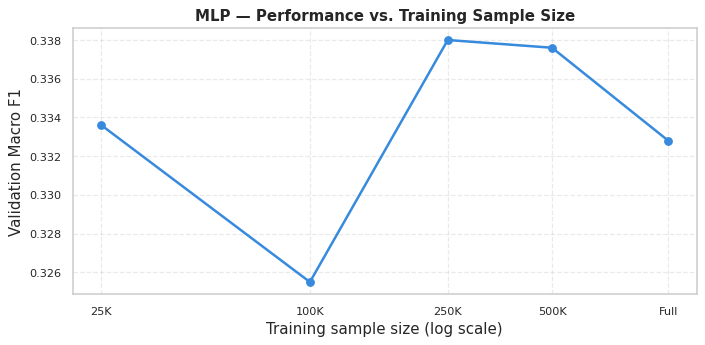


FINAL sklearn MLP TEST SET — Best model: 250K
              precision    recall  f1-score   support

Catastrophic       0.00      0.13      0.00        15
        High       0.01      0.39      0.02        66
         Low       0.71      0.67      0.69     53930
      Medium       0.06      0.60      0.11      3320
        None       0.96      0.79      0.87    174641

    accuracy                           0.76    231972
   macro avg       0.35      0.52      0.34    231972
weighted avg       0.89      0.76      0.82    231972

Macro F1 (test): 0.3375


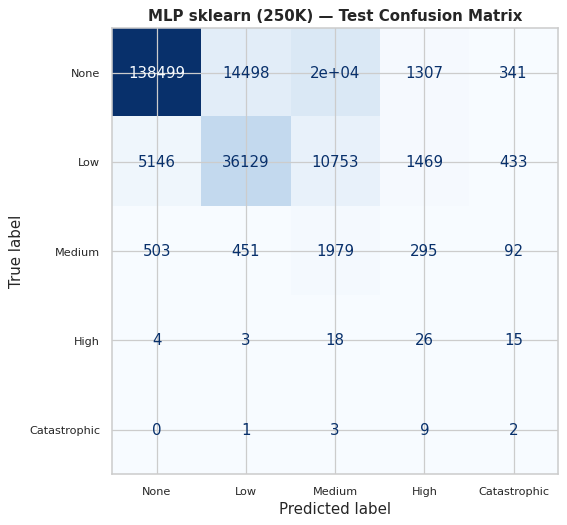

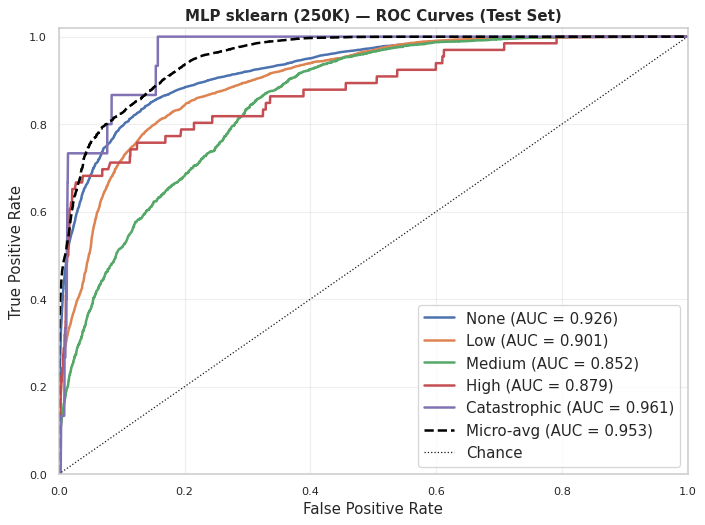

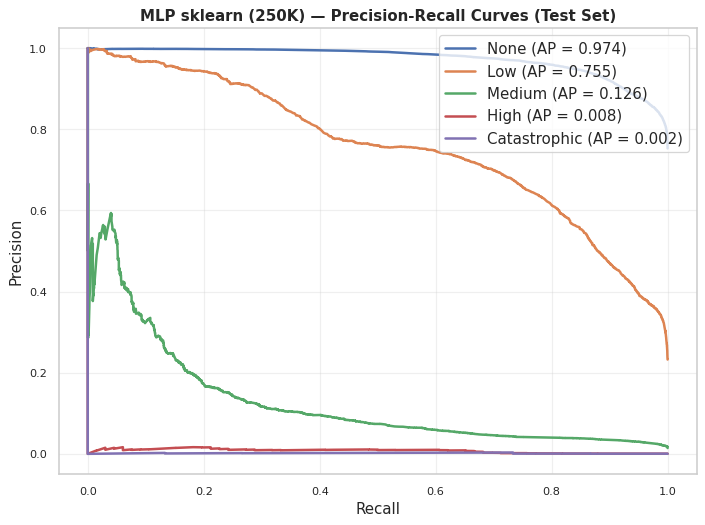


Using device: cpu

PYTORCH MLP (GPU) — Full Training Set (1,082,531 rows)
hidden=(256, 128) | activation=Tanh | solver=LBFGS

Training (full-batch LBFGS — may take a while on CPU)...
Epoch   1 | Val macro F1: 0.1728 (best: 0.1728)
Epoch   2 | Val macro F1: 0.2250 (best: 0.2250)
Epoch   3 | Val macro F1: 0.2406 (best: 0.2406)
Epoch   4 | Val macro F1: 0.2519 (best: 0.2519)
Epoch   5 | Val macro F1: 0.2596 (best: 0.2596)
Epoch   6 | Val macro F1: 0.2667 (best: 0.2667)
Epoch   7 | Val macro F1: 0.2767 (best: 0.2767)
Epoch   8 | Val macro F1: 0.2840 (best: 0.2840)
Epoch   9 | Val macro F1: 0.2919 (best: 0.2919)
Epoch  10 | Val macro F1: 0.2965 (best: 0.2965)
Epoch  11 | Val macro F1: 0.3011 (best: 0.3011)
Epoch  12 | Val macro F1: 0.3042 (best: 0.3042)
Epoch  13 | Val macro F1: 0.3068 (best: 0.3068)
Epoch  14 | Val macro F1: 0.3080 (best: 0.3080)
Epoch  15 | Val macro F1: 0.3107 (best: 0.3107)
Epoch  16 | Val macro F1: 0.3113 (best: 0.3113)
Epoch  17 | Val macro F1: 0.3121 (best: 0.3121)


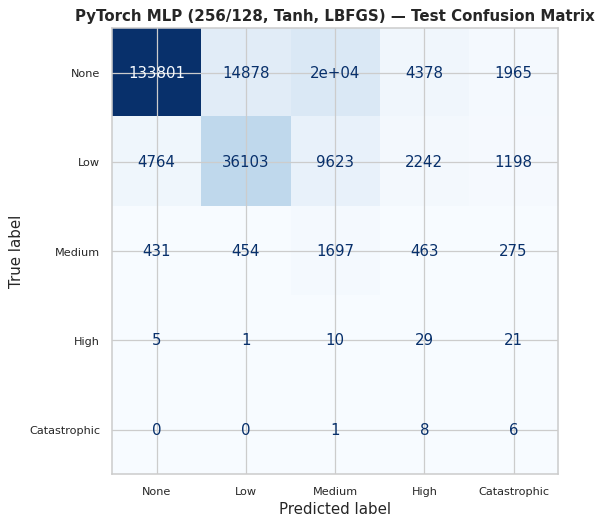

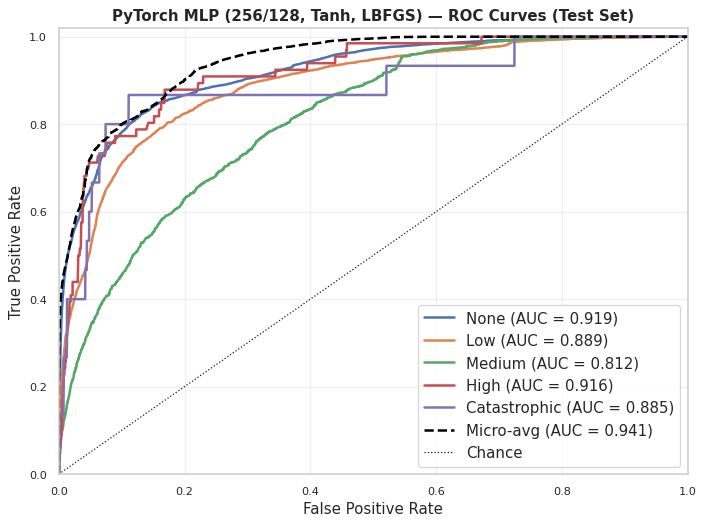

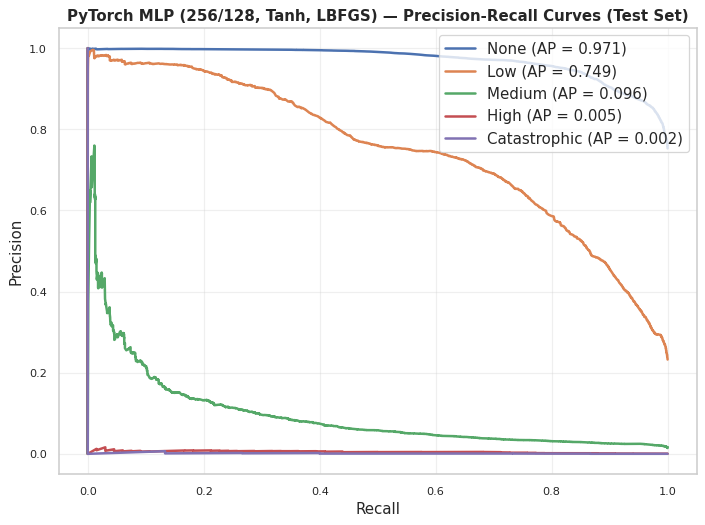


NEURAL NETWORK — FINAL SUMMARY

sklearn MLP (best sample: 250K):
  Val Macro F1 : 0.3380
  Test Macro F1: 0.3375

PyTorch MLP (256/128, Tanh, LBFGS, full dataset):
  Val Macro F1 : 0.3306
  Test Macro F1: 0.3298
  Stopped epoch: 83

Saved: mlp_sklearn_best.pkl, mlp_pytorch_best.pt


In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (roc_curve, auc, roc_auc_score,
                              precision_recall_curve, average_precision_score,
                              confusion_matrix, ConfusionMatrixDisplay)

# =============================================================================
# SECTION 1: Preprocessing Setup
# X_train_final is already one-hot encoded — only impute and scale
# =============================================================================

le_nn = LabelEncoder()
le_nn.fit(y_train)

y_train_enc = le_nn.transform(y_train)
y_val_enc   = le_nn.transform(y_val)
y_test_enc  = le_nn.transform(y_test)

print(f"Label mapping: {dict(zip(le_nn.classes_, le_nn.transform(le_nn.classes_)))}")

preprocessor_nn = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler())
])

X_train_proc = preprocessor_nn.fit_transform(X_train_final)
X_val_proc   = preprocessor_nn.transform(X_val_final)
X_test_proc  = preprocessor_nn.transform(X_test_final)

print(f"Preprocessed feature count: {X_train_proc.shape[1]}")

# =============================================================================
# SECTION 2: sklearn MLP — Scaling Experiment (25K → Full Training Set)
# =============================================================================

sample_sizes = {
    "25K"  :  25_000,
    "100K" : 100_000,
    "250K" : 250_000,
    "500K" : 500_000,
    "Full" : len(X_train)
}

mlp_results = []

for label, n in sample_sizes.items():
    print(f"\n{'='*70}")
    print(f"MLP EXPERIMENT — Training sample: {label} ({n:,} rows)")
    print(f"{'='*70}")

    if n < len(X_train):
        sss = StratifiedShuffleSplit(
            n_splits=1,
            test_size=1 - n / len(X_train),
            random_state=6704
        )
        idx, _ = next(sss.split(X_train, y_train))
    else:
        idx = np.arange(len(X_train))

    X_sample = X_train_proc[idx]
    y_sample = y_train_enc[idx]

    print(f"Class distribution in sample:")
    print(pd.Series(le_nn.inverse_transform(y_sample)).value_counts())

    sample_weights = compute_sample_weight(class_weight="balanced", y=y_sample)

    mlp_exp = MLPClassifier(
        hidden_layer_sizes=(128, 64),
        activation="relu",
        solver="adam",
        alpha=0.001,
        batch_size=512,
        learning_rate="adaptive",
        max_iter=200,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=15,
        random_state=6704,
        verbose=False
    )

    print(f"\nFitting MLP ({label})...")
    mlp_exp.fit(X_sample, y_sample, sample_weight=sample_weights)
    print(f"Stopped at iteration: {mlp_exp.n_iter_}")

    y_val_pred_enc = mlp_exp.predict(X_val_proc)
    y_val_pred     = le_nn.inverse_transform(y_val_pred_enc)
    val_f1         = f1_score(y_val, y_val_pred, average="macro", zero_division=0)

    print(f"\n--- Validation Results ({label}) ---")
    print(classification_report(y_val, y_val_pred,
          target_names=["Catastrophic", "High", "Low", "Medium", "None"],
          zero_division=0))
    print(f"Macro F1 (val): {val_f1:.4f}")

    mlp_results.append({
        "Sample"      : label,
        "N_train"     : len(y_sample),
        "N_iter"      : mlp_exp.n_iter_,
        "Val_F1_macro": round(val_f1, 4),
        "Model"       : mlp_exp
    })

# ── Comparison Table ──────────────────────────────────────────────────────────
print(f"\n{'='*70}")
print("MLP SCALING EXPERIMENT — Training Sample Size vs. Performance")
print(f"{'='*70}")

results_df = pd.DataFrame(mlp_results)[["Sample", "N_train", "N_iter", "Val_F1_macro"]]
print(results_df.to_string(index=False))

best_mlp_row = max(mlp_results, key=lambda x: x["Val_F1_macro"])
print(f"\nBest sklearn MLP: {best_mlp_row['Sample']} "
      f"(Val Macro F1: {best_mlp_row['Val_F1_macro']:.4f})")

# ── Scaling Curve Plot ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(
    [r["N_train"] for r in mlp_results],
    [r["Val_F1_macro"] for r in mlp_results],
    marker="o", color="#378ADD", linewidth=2
)
ax.set_xscale("log")
ax.set_xlabel("Training sample size (log scale)")
ax.set_ylabel("Validation Macro F1")
ax.set_title("MLP — Performance vs. Training Sample Size", weight="bold")
ax.set_xticks([25000, 100000, 250000, 500000, len(X_train)])
ax.set_xticklabels(["25K", "100K", "250K", "500K", "Full"])
ax.grid(linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

# ── Final Test Set Evaluation — Best sklearn MLP ──────────────────────────────
best_mlp        = best_mlp_row["Model"]
y_test_pred_enc = best_mlp.predict(X_test_proc)
y_test_pred     = le_nn.inverse_transform(y_test_pred_enc)
test_f1         = f1_score(y_test, y_test_pred, average="macro", zero_division=0)

print(f"\n{'='*70}")
print(f"FINAL sklearn MLP TEST SET — Best model: {best_mlp_row['Sample']}")
print(f"{'='*70}")
print(classification_report(y_test, y_test_pred,
      target_names=["Catastrophic", "High", "Low", "Medium", "None"],
      zero_division=0))
print(f"Macro F1 (test): {test_f1:.4f}")

# ── Confusion Matrix — Best sklearn MLP ──────────────────────────────────────
CLASS_ORDER_NN = ["None", "Low", "Medium", "High", "Catastrophic"]

cm_mlp = confusion_matrix(y_test, y_test_pred, labels=CLASS_ORDER_NN)
disp   = ConfusionMatrixDisplay(cm_mlp, display_labels=CLASS_ORDER_NN)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title(f"MLP sklearn ({best_mlp_row['Sample']}) — Test Confusion Matrix",
             weight="bold")
plt.tight_layout()
plt.show()

# ── ROC Curves — Best sklearn MLP ────────────────────────────────────────────
le_pr         = LabelEncoder().fit(CLASS_ORDER_NN)
y_test_enc_pr = le_pr.transform(y_test)
y_proba_mlp   = best_mlp.predict_proba(X_test_proc)
y_bin_pr      = label_binarize(y_test_enc_pr,
                classes=list(range(len(CLASS_ORDER_NN))))
present       = np.unique(y_test_enc_pr)

plt.figure(figsize=(8, 6))
for cls in CLASS_ORDER_NN:
    i = le_pr.transform([cls])[0]
    if y_bin_pr[:, i].sum() == 0:
        continue
    fpr, tpr, _ = roc_curve(y_bin_pr[:, i], y_proba_mlp[:, i])
    plt.plot(fpr, tpr, lw=2, label=f"{cls} (AUC = {auc(fpr, tpr):.3f})")

fpr_m, tpr_m, _ = roc_curve(
    y_bin_pr[:, present].ravel(),
    y_proba_mlp[:, present].ravel()
)
plt.plot(fpr_m, tpr_m, lw=2, ls="--", color="black",
         label=f"Micro-avg (AUC = {auc(fpr_m, tpr_m):.3f})")
plt.plot([0, 1], [0, 1], "k:", lw=1, label="Chance")
plt.xlim(0, 1); plt.ylim(0, 1.02)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"MLP sklearn ({best_mlp_row['Sample']}) — ROC Curves (Test Set)",
          weight="bold")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ── Precision-Recall Curves — Best sklearn MLP ───────────────────────────────
plt.figure(figsize=(8, 6))
for cls in CLASS_ORDER_NN:
    i = le_pr.transform([cls])[0]
    if y_bin_pr[:, i].sum() == 0:
        continue
    precision, recall, _ = precision_recall_curve(y_bin_pr[:, i], y_proba_mlp[:, i])
    ap = average_precision_score(y_bin_pr[:, i], y_proba_mlp[:, i])
    plt.plot(recall, precision, lw=2, label=f"{cls} (AP = {ap:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"MLP sklearn ({best_mlp_row['Sample']}) — Precision-Recall Curves (Test Set)",
          weight="bold")
plt.legend(loc="upper right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# =============================================================================
# SECTION 3: PyTorch GPU-Enabled MLP — Tuned Hyperparameters
# =============================================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nUsing device: {device}")

def to_dense(arr):
    return arr.toarray() if sp.issparse(arr) else np.asarray(arr)

X_train_dense = to_dense(X_train_proc)
X_val_dense   = to_dense(X_val_proc)
X_test_dense  = to_dense(X_test_proc)

n_features = X_train_dense.shape[1]
n_classes  = len(le_nn.classes_)

X_train_t = torch.tensor(X_train_dense, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train_enc,   dtype=torch.long).to(device)
X_val_t   = torch.tensor(X_val_dense,   dtype=torch.float32).to(device)
y_val_t   = torch.tensor(y_val_enc,     dtype=torch.long).to(device)
X_test_t  = torch.tensor(X_test_dense,  dtype=torch.float32).to(device)

class_weights_np = compute_class_weight(
    "balanced", classes=np.unique(y_train_enc), y=y_train_enc
)
class_weights_t = torch.tensor(class_weights_np, dtype=torch.float32).to(device)

class MLP(nn.Module):
    def __init__(self, input_dim, hidden_sizes, n_classes, activation_cls):
        super().__init__()
        layers, prev = [], input_dim
        for h in hidden_sizes:
            layers.append(nn.Linear(prev, h))
            layers.append(activation_cls())
            prev = h
        layers.append(nn.Linear(prev, n_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

HIDDEN_SIZES = (256, 128)
ACTIVATION   = nn.Tanh
MAX_EPOCHS   = 200
PATIENCE     = 15
BASE_LR      = 0.001
WEIGHT_DECAY = 0.001

model     = MLP(n_features, HIDDEN_SIZES, n_classes, ACTIVATION).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights_t)
optimizer = optim.LBFGS(model.parameters(), lr=BASE_LR)

def evaluate_torch(model, X, y):
    model.eval()
    with torch.no_grad():
        preds = model(X).argmax(dim=1)
        f1    = f1_score(y.cpu().numpy(), preds.cpu().numpy(),
                         average="macro", zero_division=0)
    return f1, preds.cpu().numpy()

print(f"\n{'='*70}")
print(f"PYTORCH MLP (GPU) — Full Training Set ({len(y_train_enc):,} rows)")
print(f"hidden={HIDDEN_SIZES} | activation=Tanh | solver=LBFGS")
print(f"{'='*70}")
print("\nTraining (full-batch LBFGS — may take a while on CPU)...")

best_val_f1, best_state = -1.0, None
epochs_no_improve       = 0
stopped_epoch           = MAX_EPOCHS

for epoch in range(MAX_EPOCHS):
    model.train()

    def closure():
        optimizer.zero_grad()
        loss = criterion(model(X_train_t), y_train_t)
        loss.backward()
        return loss

    optimizer.step(closure)

    val_f1, _ = evaluate_torch(model, X_val_t, y_val_t)

    if val_f1 > best_val_f1:
        best_val_f1       = val_f1
        best_state        = {k: v.clone() for k, v in model.state_dict().items()}
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    if epoch % 10 == 0 or epochs_no_improve == 0:
        print(f"Epoch {epoch+1:3d} | Val macro F1: {val_f1:.4f} "
              f"(best: {best_val_f1:.4f})")

    if epochs_no_improve >= PATIENCE:
        stopped_epoch = epoch + 1
        print(f"\nEarly stopping at epoch {stopped_epoch}.")
        break

model.load_state_dict(best_state)

val_f1_torch,  val_preds_torch  = evaluate_torch(model, X_val_t, y_val_t)
test_f1_torch, test_preds_torch = evaluate_torch(
    model, X_test_t, torch.tensor(y_test_enc).to(device)
)

val_preds_labels  = le_nn.inverse_transform(val_preds_torch)
test_preds_labels = le_nn.inverse_transform(test_preds_torch)

print(f"\n--- PyTorch MLP — Validation Results ---")
print(classification_report(y_val, val_preds_labels,
      target_names=["Catastrophic", "High", "Low", "Medium", "None"],
      zero_division=0))
print(f"Macro F1 (val): {val_f1_torch:.4f}")

print(f"\n--- PyTorch MLP — Test Results ---")
print(classification_report(y_test, test_preds_labels,
      target_names=["Catastrophic", "High", "Low", "Medium", "None"],
      zero_division=0))
print(f"Macro F1 (test): {test_f1_torch:.4f}")

# ── Confusion Matrix — PyTorch MLP ───────────────────────────────────────────
cm_torch = confusion_matrix(y_test, test_preds_labels, labels=CLASS_ORDER_NN)
disp_t   = ConfusionMatrixDisplay(cm_torch, display_labels=CLASS_ORDER_NN)
fig, ax  = plt.subplots(figsize=(8, 6))
disp_t.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("PyTorch MLP (256/128, Tanh, LBFGS) — Test Confusion Matrix",
             weight="bold")
plt.tight_layout()
plt.show()

# ── ROC Curves — PyTorch MLP ─────────────────────────────────────────────────
y_proba_torch = torch.softmax(
    model(X_test_t), dim=1
).detach().cpu().numpy()

y_test_enc_torch = le_pr.transform(y_test)
y_bin_torch      = label_binarize(y_test_enc_torch,
                   classes=list(range(len(CLASS_ORDER_NN))))
present_torch    = np.unique(y_test_enc_torch)

plt.figure(figsize=(8, 6))
for cls in CLASS_ORDER_NN:
    i = le_pr.transform([cls])[0]
    if y_bin_torch[:, i].sum() == 0:
        continue
    fpr, tpr, _ = roc_curve(y_bin_torch[:, i], y_proba_torch[:, i])
    plt.plot(fpr, tpr, lw=2, label=f"{cls} (AUC = {auc(fpr, tpr):.3f})")

fpr_m, tpr_m, _ = roc_curve(
    y_bin_torch[:, present_torch].ravel(),
    y_proba_torch[:, present_torch].ravel()
)
plt.plot(fpr_m, tpr_m, lw=2, ls="--", color="black",
         label=f"Micro-avg (AUC = {auc(fpr_m, tpr_m):.3f})")
plt.plot([0, 1], [0, 1], "k:", lw=1, label="Chance")
plt.xlim(0, 1); plt.ylim(0, 1.02)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("PyTorch MLP (256/128, Tanh, LBFGS) — ROC Curves (Test Set)",
          weight="bold")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ── Precision-Recall Curves — PyTorch MLP ────────────────────────────────────
plt.figure(figsize=(8, 6))
for cls in CLASS_ORDER_NN:
    i = le_pr.transform([cls])[0]
    if y_bin_torch[:, i].sum() == 0:
        continue
    precision, recall, _ = precision_recall_curve(
        y_bin_torch[:, i], y_proba_torch[:, i])
    ap = average_precision_score(y_bin_torch[:, i], y_proba_torch[:, i])
    plt.plot(recall, precision, lw=2, label=f"{cls} (AP = {ap:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("PyTorch MLP (256/128, Tanh, LBFGS) — Precision-Recall Curves (Test Set)",
          weight="bold")
plt.legend(loc="upper right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# =============================================================================
# FINAL SUMMARY
# =============================================================================
print(f"\n{'='*70}")
print("NEURAL NETWORK — FINAL SUMMARY")
print(f"{'='*70}")
print(f"\nsklearn MLP (best sample: {best_mlp_row['Sample']}):")
print(f"  Val Macro F1 : {best_mlp_row['Val_F1_macro']:.4f}")
print(f"  Test Macro F1: {test_f1:.4f}")
print(f"\nPyTorch MLP (256/128, Tanh, LBFGS, full dataset):")
print(f"  Val Macro F1 : {val_f1_torch:.4f}")
print(f"  Test Macro F1: {test_f1_torch:.4f}")
print(f"  Stopped epoch: {stopped_epoch}")

joblib.dump(best_mlp, "mlp_sklearn_best.pkl")
torch.save(best_state, "mlp_pytorch_best.pt")
print("\nSaved: mlp_sklearn_best.pkl, mlp_pytorch_best.pt")

## Section 10: Master Results Comparison


MASTER RESULTS TABLE — ALL EXPERIMENTS
  Model_Family                              Experiment  Val_Macro_F1  Test_Macro_F1                                         Notes
           GLM GLM Baseline (multinomial, 50 features)        0.3121            NaN                   Baseline, no penalty tuning
           GLM           GLM Elastic Net (50 features)        0.3042         0.3040                       C=1.0000, l1_ratio=0.50
 Random Forest               RF Baseline (50 features)        0.3496         0.3488              class_weight=balanced, 5-fold CV
 Random Forest           RF Without YEAR (49 features)        0.3355            NaN         YEAR identified as reporting artifact
 Random Forest                  RF SMOTE (50 features)        0.3636            NaN   SMOTE rejected — None class dominated gains
 Random Forest         RF Full Features (109 features)        0.3988         0.3966      Best RF — pre-selection full feature set
       XGBoost                        XGBoost Base

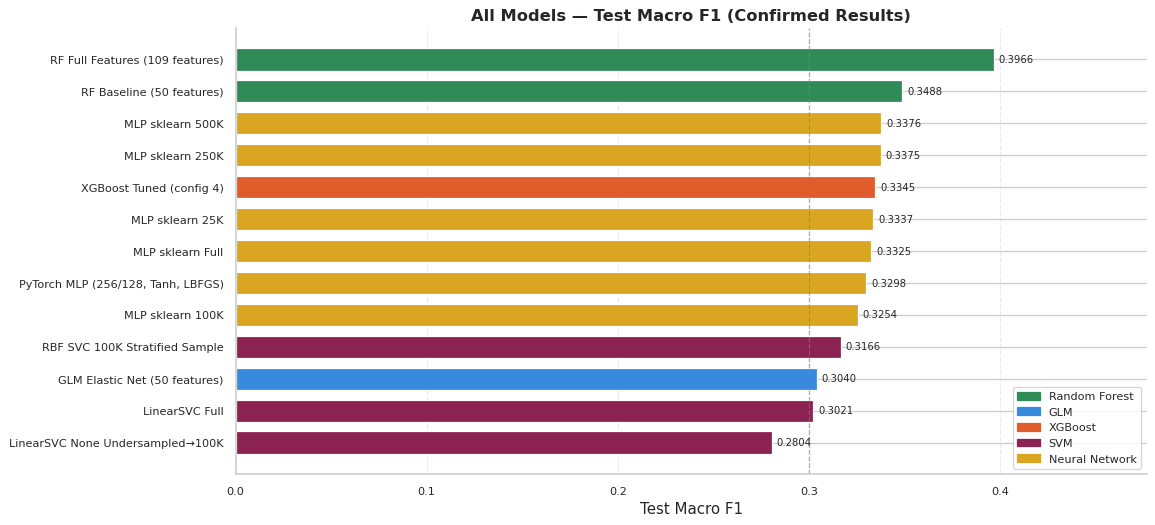

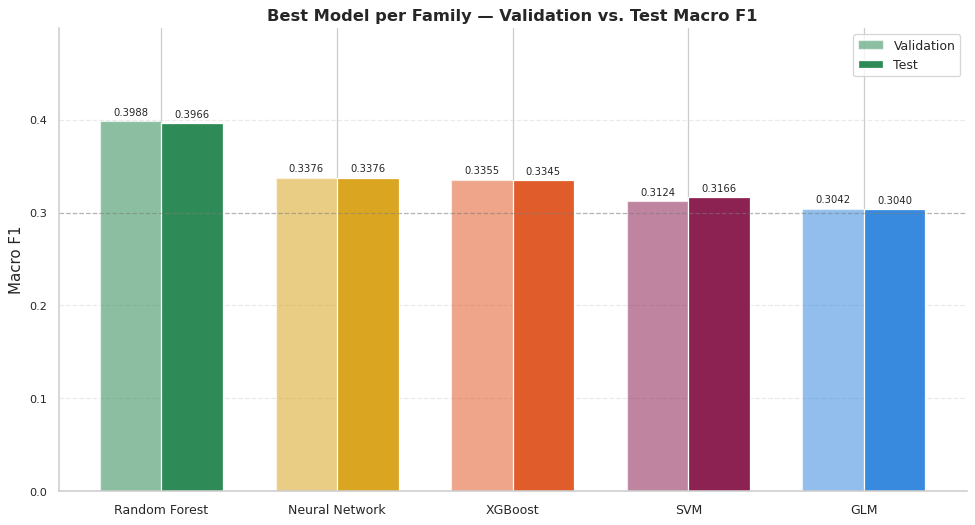

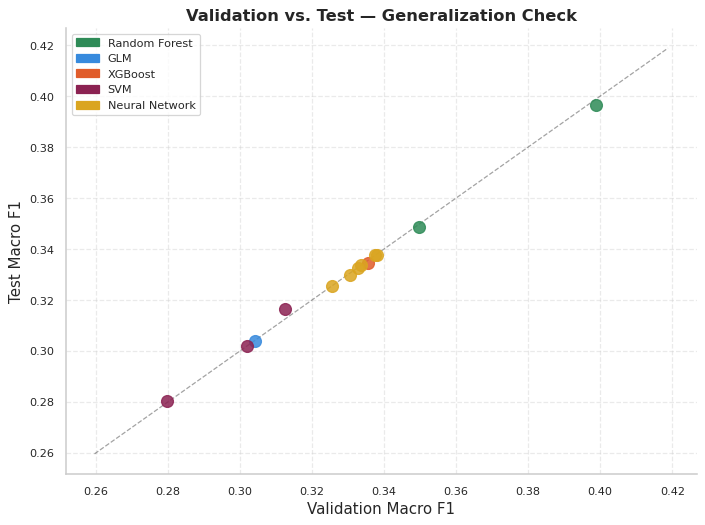

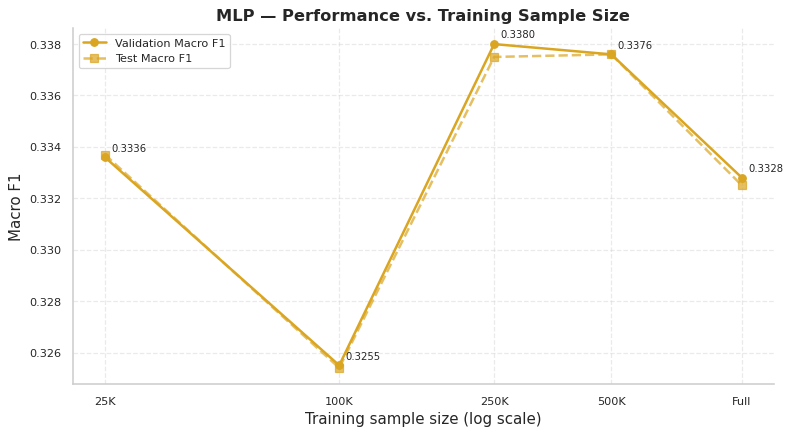


FINAL MODEL RANKING — Confirmed Test Macro F1 (descending)
        Model_Family                          Experiment  Val_Macro_F1  Test_Macro_F1
Rank                                                                                 
1      Random Forest     RF Full Features (109 features)        0.3988         0.3966
2      Random Forest           RF Baseline (50 features)        0.3496         0.3488
3     Neural Network                    MLP sklearn 500K        0.3376         0.3376
4     Neural Network                    MLP sklearn 250K        0.3380         0.3375
5            XGBoost            XGBoost Tuned (config 4)        0.3355         0.3345
6     Neural Network                     MLP sklearn 25K        0.3336         0.3337
7     Neural Network                    MLP sklearn Full        0.3328         0.3325
8     Neural Network  PyTorch MLP (256/128, Tanh, LBFGS)        0.3306         0.3298
9     Neural Network                    MLP sklearn 100K        0.3255         0

In [15]:
CLASS_ORDER = ["None", "Low", "Medium", "High", "Catastrophic"]

# =============================================================================
# SECTION 1: Collect Results from All Model Sections
# =============================================================================

def safe_f1(y_true, y_pred, label):
    """Compute macro F1, handling mixed string/integer label types."""
    try:
        if y_pred is None:
            return None
        y_true = np.array(y_true).astype(str)
        y_pred = np.array(y_pred).astype(str)
        return round(f1_score(y_true, y_pred, average="macro", zero_division=0), 4)
    except Exception as e:
        print(f"  Warning [{label}]: {e}")
        return None

results_rows = []

# ── GLM — Akila ───────────────────────────────────────────────────────────────
print("Collecting GLM results...")

try:
    results_rows.append({
        "Model_Family" : "GLM",
        "Experiment"   : "GLM Baseline (multinomial, 50 features)",
        "Val_Macro_F1" : safe_f1(y_val, y_val_pred_glm_base,  "GLM Baseline Val"),
        "Test_Macro_F1": None,
        "Notes"        : "Baseline, no penalty tuning"
    })
except NameError:
    results_rows.append({"Model_Family":"GLM","Experiment":"GLM Baseline",
                         "Val_Macro_F1":None,"Test_Macro_F1":None,
                         "Notes":"Section not run"})

try:
    results_rows.append({
        "Model_Family" : "GLM",
        "Experiment"   : "GLM Elastic Net (50 features)",
        "Val_Macro_F1" : safe_f1(y_val, y_val_pred_glm_tuned,  "GLM Tuned Val"),
        "Test_Macro_F1": safe_f1(y_test, y_test_pred_glm_tuned, "GLM Tuned Test"),
        "Notes"        : f"C={glm_cv.C_[0]:.4f}, l1_ratio={glm_cv.l1_ratio_[0]:.2f}"
    })
except NameError:
    results_rows.append({"Model_Family":"GLM","Experiment":"GLM Elastic Net",
                         "Val_Macro_F1":None,"Test_Macro_F1":None,
                         "Notes":"Section not run"})

# ── Random Forest — Alejandro ─────────────────────────────────────────────────
print("Collecting Random Forest results...")

for exp_label, val_pred_var, test_pred_var, notes in [
    ("RF Baseline (50 features)",       "y_val_pred_rf_baseline", "y_test_pred_rf_baseline", "class_weight=balanced, 5-fold CV"),
    ("RF Without YEAR (49 features)",   "y_val_pred_no_year",     None,                       "YEAR identified as reporting artifact"),
    ("RF SMOTE (50 features)",          "y_val_pred_smote",       None,                       "SMOTE rejected — None class dominated gains"),
    ("RF Full Features (109 features)", "y_val_pred_rf_full",     "y_test_pred_rf_final",     "Best RF — pre-selection full feature set"),
]:
    try:
        val_pred  = eval(val_pred_var) if val_pred_var else None
        test_pred = eval(test_pred_var) if test_pred_var else None
        results_rows.append({
            "Model_Family" : "Random Forest",
            "Experiment"   : exp_label,
            "Val_Macro_F1" : safe_f1(y_val,  val_pred,  exp_label) if val_pred  is not None else None,
            "Test_Macro_F1": safe_f1(y_test, test_pred, exp_label) if test_pred is not None else None,
            "Notes"        : notes
        })
    except NameError:
        results_rows.append({"Model_Family":"Random Forest","Experiment":exp_label,
                             "Val_Macro_F1":None,"Test_Macro_F1":None,
                             "Notes":"Section not run"})

# ── XGBoost — Sanjana ────────────────────────────────────────────────────────
print("Collecting XGBoost results...")

try:
    results_rows.append({
        "Model_Family" : "XGBoost",
        "Experiment"   : "XGBoost Baseline",
        "Val_Macro_F1" : safe_f1(y_val, y_val_pred_xgb_base,  "XGB Baseline Val"),
        "Test_Macro_F1": None,
        "Notes"        : "depth=6, lr=0.1, early stopping"
    })
    results_rows.append({
        "Model_Family" : "XGBoost",
        "Experiment"   : f"XGBoost Tuned (config {best_config_id})",
        "Val_Macro_F1" : safe_f1(y_val, y_val_pred_xgb_tuned,  "XGB Tuned Val"),
        "Test_Macro_F1": safe_f1(y_test, y_test_pred_xgb_tuned, "XGB Tuned Test"),
        "Notes"        : f"depth={BEST_PARAMS['max_depth']}, lr={BEST_PARAMS['learning_rate']}, n_est={BEST_N_ESTIMATORS}, 5-fold CV"
    })
except NameError:
    for exp in ["XGBoost Baseline", "XGBoost Tuned"]:
        results_rows.append({"Model_Family":"XGBoost","Experiment":exp,
                             "Val_Macro_F1":None,"Test_Macro_F1":None,
                             "Notes":"Section not run"})

# ── SVM — Harris / Alejandro ─────────────────────────────────────────────────
print("Collecting SVM results...")

for exp_label, val_pred_var, test_pred_var, notes in [
    ("LinearSVC Full",                   "y_val_pred_lf", "y_test_pred_lf", "CalibratedClassifierCV, class_weight=balanced"),
    ("LinearSVC None Undersampled→100K", "y_val_pred_lu", "y_test_pred_lu", "RandomUnderSampler, class_weight=balanced"),
    ("RBF SVC 100K Stratified Sample",   "y_val_pred_rs", "y_test_pred_rs", "kernel=rbf, C=1.0, gamma=scale"),
]:
    try:
        val_pred  = eval(val_pred_var)
        test_pred = eval(test_pred_var)
        results_rows.append({
            "Model_Family" : "SVM",
            "Experiment"   : exp_label,
            "Val_Macro_F1" : safe_f1(y_val, val_pred,  exp_label),
            "Test_Macro_F1": safe_f1(y_test, test_pred, exp_label),
            "Notes"        : notes
        })
    except NameError:
        results_rows.append({"Model_Family":"SVM","Experiment":exp_label,
                             "Val_Macro_F1":None,"Test_Macro_F1":None,
                             "Notes":"Section not run"})

# ── Neural Network — Harris ───────────────────────────────────────────────────
print("Collecting Neural Network results...")

for r in (mlp_results if "mlp_results" in dir() else []):
    try:
        y_pred_enc = r["Model"].predict(X_test_proc)
        y_pred_lab = le_nn.inverse_transform(y_pred_enc)
        results_rows.append({
            "Model_Family" : "Neural Network",
            "Experiment"   : f"MLP sklearn {r['Sample']}",
            "Val_Macro_F1" : r["Val_F1_macro"],
            "Test_Macro_F1": safe_f1(y_test, y_pred_lab, f"MLP {r['Sample']} Test"),
            "Notes"        : f"128/64, ReLU, Adam, early stopping, n_iter={r['N_iter']}"
        })
    except Exception as e:
        print(f"  Warning [MLP {r['Sample']}]: {e}")

try:
    results_rows.append({
        "Model_Family" : "Neural Network",
        "Experiment"   : "PyTorch MLP (256/128, Tanh, LBFGS)",
        "Val_Macro_F1" : round(val_f1_torch, 4),
        "Test_Macro_F1": round(test_f1_torch, 4),
        "Notes"        : f"GPU-enabled, full dataset, stopped epoch {stopped_epoch}"
    })
except NameError:
    results_rows.append({"Model_Family":"Neural Network","Experiment":"PyTorch MLP",
                         "Val_Macro_F1":None,"Test_Macro_F1":None,
                         "Notes":"Section not run"})

# =============================================================================
# SECTION 2: Build Master Table
# =============================================================================

results   = pd.DataFrame(results_rows)
confirmed = results[results["Test_Macro_F1"].notna()].copy()

print("\n" + "=" * 80)
print("MASTER RESULTS TABLE — ALL EXPERIMENTS")
print("=" * 80)
print(results[["Model_Family", "Experiment", "Val_Macro_F1",
               "Test_Macro_F1", "Notes"]].to_string(index=False))

pending = results[results["Test_Macro_F1"].isna()]
if len(pending) > 0:
    print(f"\nPending results ({len(pending)} experiments):")
    print(pending[["Model_Family", "Experiment", "Notes"]].to_string(index=False))

# =============================================================================
# SECTION 3: Best Per Family
# =============================================================================

best_per_family = (
    confirmed.groupby("Model_Family")
    .apply(lambda g: g.loc[g["Test_Macro_F1"].idxmax()])
    .reset_index(drop=True)
    [["Model_Family", "Experiment", "Val_Macro_F1", "Test_Macro_F1", "Notes"]]
    .sort_values("Test_Macro_F1", ascending=False)
)

print("\n" + "=" * 80)
print("BEST MODEL PER FAMILY")
print("=" * 80)
print(best_per_family.to_string(index=False))

# =============================================================================
# SECTION 4: Visualizations
# =============================================================================

FAMILY_COLORS = {
    "Random Forest" : "#2E8B57",
    "GLM"           : "#378ADD",
    "XGBoost"       : "#E05C2A",
    "SVM"           : "#8B2252",
    "Neural Network": "#DAA520",
}

# ── Plot 1: All confirmed experiments — horizontal bar ────────────────────────
confirmed_sorted = confirmed.sort_values("Test_Macro_F1", ascending=True)

fig, ax = plt.subplots(figsize=(13, max(6, len(confirmed_sorted) * 0.45)))
bar_colors = [FAMILY_COLORS.get(f, "gray") for f in confirmed_sorted["Model_Family"]]
bars = ax.barh(confirmed_sorted["Experiment"], confirmed_sorted["Test_Macro_F1"],
               color=bar_colors, edgecolor="white", height=0.7)
ax.axvline(x=0.30, color="gray", linestyle="--", linewidth=1, alpha=0.6)
ax.bar_label(bars, fmt="%.4f", padding=4, fontsize=8)
ax.set_xlabel("Test Macro F1")
ax.set_title("All Models — Test Macro F1 (Confirmed Results)",
             weight="bold", fontsize=13)
ax.set_xlim(0, confirmed_sorted["Test_Macro_F1"].max() + 0.08)
ax.grid(axis="x", linestyle="--", alpha=0.4)
legend_patches = [mpatches.Patch(color=FAMILY_COLORS[f], label=f)
                  for f in FAMILY_COLORS if f in confirmed_sorted["Model_Family"].values]
ax.legend(handles=legend_patches, loc="lower right", fontsize=9)
sns.despine()
plt.tight_layout()
plt.show()

# ── Plot 2: Best per family — val vs test grouped bar ─────────────────────────
families   = best_per_family["Model_Family"].tolist()
val_scores = best_per_family["Val_Macro_F1"].tolist()
tst_scores = best_per_family["Test_Macro_F1"].tolist()
x = np.arange(len(families))
w = 0.35

fig, ax = plt.subplots(figsize=(11, 6))
bv = ax.bar(x - w/2, val_scores,  w, label="Validation",
            color=[FAMILY_COLORS.get(f, "gray") for f in families],
            alpha=0.55, edgecolor="white")
bt = ax.bar(x + w/2, tst_scores, w, label="Test",
            color=[FAMILY_COLORS.get(f, "gray") for f in families],
            alpha=1.0, edgecolor="white")
ax.bar_label(bv, fmt="%.4f", padding=3, fontsize=8)
ax.bar_label(bt, fmt="%.4f", padding=3, fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(families, fontsize=10)
ax.set_ylabel("Macro F1")
ax.set_title("Best Model per Family — Validation vs. Test Macro F1",
             weight="bold", fontsize=13)
valid_scores = [s for s in val_scores + tst_scores
                if s is not None and not np.isnan(float(s))]
ax.set_ylim(0, max(valid_scores) + 0.1 if valid_scores else 1.0)
ax.axhline(y=0.30, color="gray", linestyle="--", linewidth=1, alpha=0.5)
ax.legend(fontsize=10)
ax.grid(axis="y", linestyle="--", alpha=0.4)
sns.despine()
plt.tight_layout()
plt.show()

# ── Plot 3: Val vs Test scatter — generalization check ────────────────────────
confirmed_both = confirmed[
    confirmed["Val_Macro_F1"].notna() & confirmed["Test_Macro_F1"].notna()
].copy()

if len(confirmed_both) > 0:
    fig, ax = plt.subplots(figsize=(8, 6))
    for _, row in confirmed_both.iterrows():
        color = FAMILY_COLORS.get(row["Model_Family"], "gray")
        ax.scatter(row["Val_Macro_F1"], row["Test_Macro_F1"],
                   color=color, s=90, alpha=0.85, zorder=3)
    lim_min = float(confirmed_both[["Val_Macro_F1","Test_Macro_F1"]].min().min()) - 0.02
    lim_max = float(confirmed_both[["Val_Macro_F1","Test_Macro_F1"]].max().max()) + 0.02
    ax.plot([lim_min, lim_max], [lim_min, lim_max], "k--",
            linewidth=1, alpha=0.4, label="Val = Test")
    ax.set_xlabel("Validation Macro F1")
    ax.set_ylabel("Test Macro F1")
    ax.set_title("Validation vs. Test — Generalization Check",
                 weight="bold", fontsize=13)
    legend_patches = [mpatches.Patch(color=FAMILY_COLORS[f], label=f)
                      for f in FAMILY_COLORS if f in confirmed_both["Model_Family"].values]
    ax.legend(handles=legend_patches, fontsize=9)
    ax.grid(linestyle="--", alpha=0.4)
    sns.despine()
    plt.tight_layout()
    plt.show()

# ── Plot 4: MLP scaling curve ─────────────────────────────────────────────────
mlp_rows = results[
    results["Experiment"].str.startswith("MLP sklearn") &
    results["Val_Macro_F1"].notna()
].copy()

if len(mlp_rows) > 1:
    size_map = {
        "MLP sklearn 25K" : 25_000,
        "MLP sklearn 100K": 100_000,
        "MLP sklearn 250K": 250_000,
        "MLP sklearn 500K": 500_000,
        "MLP sklearn Full": 1_082_531
    }
    mlp_rows["N"] = mlp_rows["Experiment"].map(size_map)
    mlp_rows = mlp_rows.dropna(subset=["N"]).sort_values("N")

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(mlp_rows["N"], mlp_rows["Val_Macro_F1"],
            marker="o", color=FAMILY_COLORS["Neural Network"],
            linewidth=2, label="Validation Macro F1")
    if mlp_rows["Test_Macro_F1"].notna().any():
        ax.plot(mlp_rows["N"], mlp_rows["Test_Macro_F1"],
                marker="s", color=FAMILY_COLORS["Neural Network"],
                linewidth=2, linestyle="--", alpha=0.7, label="Test Macro F1")
    ax.set_xscale("log")
    ax.set_xlabel("Training sample size (log scale)")
    ax.set_ylabel("Macro F1")
    ax.set_title("MLP — Performance vs. Training Sample Size",
                 weight="bold", fontsize=13)
    ticks = mlp_rows["N"].tolist()
    ax.set_xticks(ticks)
    ax.set_xticklabels(["25K", "100K", "250K", "500K", "Full"][:len(ticks)])
    ax.legend(fontsize=9)
    ax.grid(linestyle="--", alpha=0.4)
    for _, row in mlp_rows.iterrows():
        ax.annotate(f"{row['Val_Macro_F1']:.4f}",
                    (row["N"], row["Val_Macro_F1"]),
                    textcoords="offset points", xytext=(5, 5), fontsize=8)
    sns.despine()
    plt.tight_layout()
    plt.show()

# =============================================================================
# SECTION 5: Final Ranking
# =============================================================================

print("\n" + "=" * 80)
print("FINAL MODEL RANKING — Confirmed Test Macro F1 (descending)")
print("=" * 80)

final_ranking = (
    confirmed[["Model_Family", "Experiment", "Val_Macro_F1", "Test_Macro_F1"]]
    .sort_values("Test_Macro_F1", ascending=False)
    .reset_index(drop=True)
)
final_ranking.index += 1
final_ranking.index.name = "Rank"
print(final_ranking.to_string())

best = final_ranking.loc[final_ranking["Test_Macro_F1"].idxmax()]
print(f"\nOverall best model : {best['Experiment']}")
print(f"Model family       : {best['Model_Family']}")
print(f"Test Macro F1      : {best['Test_Macro_F1']:.4f}")
print(f"Val  Macro F1      : {best['Val_Macro_F1']:.4f}")